# Task 6 — Full-Sample In-Sample Optimization

This notebook performs a single full-sample optimization of the validated
Channel WithDDControl strategy on CBOT Soybeans (SY).

Unlike the rolling walk-forward framework in Task 5, the entire available
historical dataset is treated as one in-sample period. The objective is to
identify the globally optimal parameter pair over the prescribed exhaustive
search grid and evaluate the corresponding idealized in-sample performance.

The optimization uses:

- `ChnLen = 500, 510, ..., 10,000` — 951 values;
- `StpPct = 0.005, 0.006, ..., 0.100` — 96 values;
- `951 × 96 = 91,296` total parameter combinations;
- optimization objective = `Net Profit / |Maximum Drawdown|`.

The strategy logic, contract economics, channel construction, and performance
definitions are kept consistent with the validated implementations used in
Tasks 4 and 5.

Task 6 is intentionally an in-sample benchmark rather than an out-of-sample
test. Its results will later be compared with the rolling OOS results from
Task 5.

In [1]:
# 0. Imports and Configuration

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import time
import warnings

warnings.filterwarnings('ignore')

pd.set_option(
    'display.max_columns',
    30
)

pd.set_option(
    'display.width',
    180
)

pd.set_option(
    'display.float_format',
    '{:,.4f}'.format
)


# ============================================================
# Validated Task 2 dataset
# ============================================================

CLEAN = (
    Path('data')
    / 'clean'
)

SY_PATH = (
    CLEAN
    / 'SY.parquet'
)


# ============================================================
# SY contract economics
# ============================================================

PV = 50.0

SLPG = 35.5

INITIAL_EQUITY = 100_000.0


# ============================================================
# Professor-required exhaustive parameter grid
# ============================================================

CHNLEN_RANGE = np.arange(
    500,
    10_001,
    10
)

STPPCT_RANGE = np.round(
    np.arange(
        0.005,
        0.101,
        0.001
    ),
    3
)


# ============================================================
# Configuration summary
# ============================================================

print('=' * 68)
print('TASK 6 — FULL-SAMPLE OPTIMIZATION CONFIGURATION')
print('=' * 68)

print(
    f'Point value          : '
    f'${PV:g}'
)

print(
    f'Round-turn slippage  : '
    f'${SLPG:.2f}'
)

print(
    f'Initial equity       : '
    f'${INITIAL_EQUITY:,.2f}'
)

print()

print(
    f'ChnLen grid size     : '
    f'{len(CHNLEN_RANGE)}'
)

print(
    f'StpPct grid size     : '
    f'{len(STPPCT_RANGE)}'
)

print(
    f'Total combinations   : '
    f'{len(CHNLEN_RANGE) * len(STPPCT_RANGE):,}'
)

TASK 6 — FULL-SAMPLE OPTIMIZATION CONFIGURATION
Point value          : $50
Round-turn slippage  : $35.50
Initial equity       : $100,000.00

ChnLen grid size     : 951
StpPct grid size     : 96
Total combinations   : 91,296


## 1. Load Validated Full-Sample SY Data

Task 6 uses the cleaned SY dataset produced in Task 2 rather than repeating raw
data cleaning inside the optimization notebook.

The complete available history is treated as one in-sample period. This ensures
that Task 5 and Task 6 use identical observations and contract assumptions, so
their later comparison isolates the difference between rolling walk-forward
parameter selection and full-sample optimization.

In [2]:
if not SY_PATH.exists():

    raise FileNotFoundError(
        f'{SY_PATH} not found. '
        f'Please run Task 2 first.'
    )


sy = pd.read_parquet(
    SY_PATH
).copy()


# ------------------------------------------------------------
# Timestamp normalization
# ------------------------------------------------------------

sy['ts'] = pd.to_datetime(
    sy['ts']
)


# ------------------------------------------------------------
# Required columns
# ------------------------------------------------------------

required_cols = [
    'ts',
    'Open',
    'High',
    'Low',
    'Close'
]

missing_cols = [
    col
    for col in required_cols
    if col not in sy.columns
]

if missing_cols:

    raise ValueError(
        'SY cleaned dataset is missing required columns: '
        f'{missing_cols}'
    )


# ------------------------------------------------------------
# Strict chronological ordering
# ------------------------------------------------------------

sy = (
    sy
    .sort_values('ts')
    .drop_duplicates(
        subset='ts',
        keep='last'
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Numerical arrays used by the optimization engine
# ------------------------------------------------------------

TS = sy[
    'ts'
].to_numpy()

O = sy[
    'Open'
].to_numpy(
    dtype=np.float64
)

H = sy[
    'High'
].to_numpy(
    dtype=np.float64
)

L = sy[
    'Low'
].to_numpy(
    dtype=np.float64
)

C = sy[
    'Close'
].to_numpy(
    dtype=np.float64
)

N = len(
    sy
)


# ============================================================
# Dataset summary
# ============================================================

print('=' * 68)
print('VALIDATED FULL-SAMPLE SY DATA')
print('=' * 68)

print(
    f'Rows                 : '
    f'{N:,}'
)

print(
    f'Date range           : '
    f'{sy["ts"].min()} → '
    f'{sy["ts"].max()}'
)

print(
    f'First close          : '
    f'{C[0]:,.2f}'
)

print(
    f'Last close           : '
    f'{C[-1]:,.2f}'
)

print(
    f'Duplicate timestamps : '
    f'{sy["ts"].duplicated().sum()}'
)

print(
    f'Missing OHLC values  : '
    f'{sy[["Open", "High", "Low", "Close"]].isna().sum().sum()}'
)

VALIDATED FULL-SAMPLE SY DATA
Rows                 : 495,740
Date range           : 1982-07-01 09:35:00 → 2026-04-10 13:15:00
First close          : 617.50
Last close           : 1,175.25
Duplicate timestamps : 0
Missing OHLC values  : 0


## 2. Validated Full-Sample Optimization Engine

Task 6 uses the same strategy logic and exhaustive-search architecture validated
in Tasks 4 and 5.

Breakout channels are constructed from prior bars only:

- `HH[k] = max(High[k-ChnLen : k])`
- `LL[k] = min(Low[k-ChnLen : k])`

The current bar is therefore excluded from channel construction.

To make the full 91,296-combination search computationally practical, rolling
channel extrema are calculated with a linear-time monotonic deque, while the
strategy-scoring loop is compiled with Numba. Parallel evaluation is applied
across the `StpPct` grid for each fixed `ChnLen`.

The computational acceleration changes only implementation speed; the parameter
grid, trading rules, transaction-cost assumptions, and optimization objective
remain unchanged.

In [3]:
from numba import njit, prange, get_num_threads

### 2.1 Strategy Scoring Engine

The scoring engine implements the validated Channel WithDDControl trading logic
for a fixed `ChnLen` and `StpPct`.

For each parameter pair, it returns:

- net profit;
- maximum dollar drawdown;
- the optimization objective `Net Profit / |Maximum Drawdown|`.

The implementation follows the same position, reversal, trailing-stop, and
transaction-cost conventions used in the validated strategy engine from Tasks 4
and 5.

In [4]:
from numba import njit, prange, get_num_threads


@njit(cache=True)
def score_strategy_fast(
    high,
    low,
    close,
    hh,
    ll,
    start_idx,
    stp_pct,
    slpg,
    pv,
    initial_equity
):
    """
    Lightweight Channel WithDDControl scoring engine.

    Returns
    -------
    net_profit
    max_drawdown
    objective = Net Profit / |Maximum Drawdown|
    """

    n = len(close)

    position = 0

    benchmark_long = np.nan
    benchmark_short = np.nan

    equity = initial_equity
    equity_max = initial_equity
    max_drawdown = 0.0

    for k in range(start_idx, n):

        # ----------------------------------------------------
        # Mark-to-market P&L
        # ----------------------------------------------------

        delta = (
            pv
            * (close[k] - close[k - 1])
            * position
        )

        traded = False

        # ====================================================
        # FLAT
        # ====================================================

        if position == 0:

            buy_signal = (
                high[k] >= hh[k]
            )

            sell_signal = (
                low[k] <= ll[k]
            )

            # Both channels crossed on the same bar
            if buy_signal and sell_signal:

                delta = (
                    -slpg
                    + pv * (
                        ll[k] - hh[k]
                    )
                )

            # Enter long
            elif buy_signal:

                delta = (
                    -slpg / 2.0
                    + pv * (
                        close[k] - hh[k]
                    )
                )

                position = 1
                traded = True

                benchmark_long = high[k]
                benchmark_short = np.nan

            # Enter short
            elif sell_signal:

                delta = (
                    -slpg / 2.0
                    - pv * (
                        close[k] - ll[k]
                    )
                )

                position = -1
                traded = True

                benchmark_short = low[k]
                benchmark_long = np.nan

        # ====================================================
        # LONG
        # ====================================================

        if position == 1 and not traded:

            channel_reverse = (
                low[k] <= ll[k]
            )

            stop_price = (
                benchmark_long
                * (1.0 - stp_pct)
            )

            stop_trigger = (
                low[k] <= stop_price
            )

            # Long -> short reversal
            if channel_reverse and stop_trigger:

                delta = (
                    delta
                    - slpg
                    - 2.0 * pv * (
                        close[k] - ll[k]
                    )
                )

                position = -1
                benchmark_short = low[k]

            else:

                # Long trailing-stop exit
                if stop_trigger:

                    delta = (
                        delta
                        - slpg / 2.0
                        - pv * (
                            close[k] - stop_price
                        )
                    )

                    position = 0

                # Long -> short reversal
                if channel_reverse:

                    delta = (
                        delta
                        - slpg
                        - 2.0 * pv * (
                            close[k] - ll[k]
                        )
                    )

                    position = -1
                    benchmark_short = low[k]

            benchmark_long = max(
                high[k],
                benchmark_long
            )

        # ====================================================
        # SHORT
        # ====================================================

        if position == -1 and not traded:

            channel_reverse = (
                high[k] >= hh[k]
            )

            stop_price = (
                benchmark_short
                * (1.0 + stp_pct)
            )

            stop_trigger = (
                high[k] >= stop_price
            )

            # Short -> long reversal
            if channel_reverse and stop_trigger:

                delta = (
                    delta
                    - slpg
                    + 2.0 * pv * (
                        close[k] - hh[k]
                    )
                )

                position = 1
                benchmark_long = high[k]

            else:

                # Short trailing-stop exit
                if stop_trigger:

                    delta = (
                        delta
                        - slpg / 2.0
                        + pv * (
                            close[k] - stop_price
                        )
                    )

                    position = 0

                # Short -> long reversal
                if channel_reverse:

                    delta = (
                        delta
                        - slpg
                        + 2.0 * pv * (
                            close[k] - hh[k]
                        )
                    )

                    position = 1
                    benchmark_long = high[k]

            benchmark_short = min(
                low[k],
                benchmark_short
            )

        # ====================================================
        # Equity and drawdown update
        # ====================================================

        equity += delta

        if equity > equity_max:
            equity_max = equity

        drawdown = (
            equity
            - equity_max
        )

        if drawdown < max_drawdown:
            max_drawdown = drawdown

    # ========================================================
    # Final statistics
    # ========================================================

    net_profit = (
        equity
        - initial_equity
    )

    if max_drawdown < 0:

        objective = (
            net_profit
            / abs(max_drawdown)
        )

    elif net_profit > 0:

        objective = net_profit

    else:

        objective = -np.inf

    return (
        net_profit,
        max_drawdown,
        objective
    )


print('2.1 Strategy scoring engine ready.')

2.1 Strategy scoring engine ready.


### 2.2 Prior-Bar Channel Construction

For each candidate `ChnLen`, the breakout channel is constructed exclusively
from the preceding observations:

- `HH[k] = max(High[k-ChnLen : k])`
- `LL[k] = min(Low[k-ChnLen : k])`

The current bar is excluded to prevent look-ahead bias.

Because the same rolling extrema must be evaluated repeatedly during exhaustive
optimization, a monotonic-deque algorithm is used to construct both channels in
linear time, `O(N)`, for each `ChnLen`.

In [5]:
@njit(cache=True)
def build_channels_deque(
    high,
    low,
    chn_len
):
    """
    Construct prior-bar breakout channels using monotonic deques.

    For each bar k:

        HH[k] = max(high[k-chn_len : k])
        LL[k] = min(low[k-chn_len : k])

    The current bar k is excluded from both channels.
    """

    n = len(high)

    hh = np.full(
        n,
        np.nan,
        dtype=np.float64
    )

    ll = np.full(
        n,
        np.nan,
        dtype=np.float64
    )

    # --------------------------------------------------------
    # Deque storage
    # --------------------------------------------------------

    max_idx = np.empty(
        n,
        dtype=np.int64
    )

    min_idx = np.empty(
        n,
        dtype=np.int64
    )

    max_head = 0
    max_tail = 0

    min_head = 0
    min_tail = 0

    # ========================================================
    # Main loop
    # ========================================================

    for k in range(n):

        # ----------------------------------------------------
        # Remove observations outside the prior ChnLen window
        # ----------------------------------------------------

        min_valid_idx = (
            k - chn_len
        )

        while (
            max_head < max_tail
            and max_idx[max_head] < min_valid_idx
        ):
            max_head += 1

        while (
            min_head < min_tail
            and min_idx[min_head] < min_valid_idx
        ):
            min_head += 1

        # ----------------------------------------------------
        # Record channel BEFORE adding the current bar
        # ----------------------------------------------------

        if k >= chn_len:

            hh[k] = high[
                max_idx[max_head]
            ]

            ll[k] = low[
                min_idx[min_head]
            ]

        # ----------------------------------------------------
        # Update maximum deque with current High
        # ----------------------------------------------------

        while (
            max_head < max_tail
            and high[max_idx[max_tail - 1]] <= high[k]
        ):
            max_tail -= 1

        max_idx[max_tail] = k
        max_tail += 1

        # ----------------------------------------------------
        # Update minimum deque with current Low
        # ----------------------------------------------------

        while (
            min_head < min_tail
            and low[min_idx[min_tail - 1]] >= low[k]
        ):
            min_tail -= 1

        min_idx[min_tail] = k
        min_tail += 1

    return (
        hh,
        ll
    )


print('2.2 Prior-bar channel builder ready.')

2.2 Prior-bar channel builder ready.


### 2.3 Parallel Stop-Grid Evaluation

For a fixed `ChnLen`, the corresponding prior-bar breakout channels are
constructed only once.

All 96 candidate `StpPct` values are then evaluated against the same channel
series. Numba parallelization is applied across the stop-parameter grid to
accelerate the exhaustive search without changing the strategy logic or
optimization objective.

For each `StpPct`, the routine records:

- net profit;
- maximum dollar drawdown;
- `Net Profit / |Maximum Drawdown|`.

In [6]:
@njit(
    cache=True,
    parallel=True
)
def score_stop_grid_parallel(
    high,
    low,
    close,
    hh,
    ll,
    start_idx,
    stp_grid,
    slpg,
    pv,
    initial_equity
):
    """
    Evaluate all StpPct candidates in parallel for one fixed
    ChnLen and its corresponding HH / LL channel series.

    Returns
    -------
    profits : ndarray
        Net profit for each StpPct.

    maxdds : ndarray
        Maximum dollar drawdown for each StpPct.

    scores : ndarray
        Optimization objective:
        Net Profit / |Maximum Drawdown|.
    """

    n_stp = len(
        stp_grid
    )

    profits = np.empty(
        n_stp,
        dtype=np.float64
    )

    maxdds = np.empty(
        n_stp,
        dtype=np.float64
    )

    scores = np.empty(
        n_stp,
        dtype=np.float64
    )

    # --------------------------------------------------------
    # Each StpPct is independent and can be evaluated in
    # parallel using the same fixed HH / LL channels.
    # --------------------------------------------------------

    for j in prange(
        n_stp
    ):

        (
            net_profit,
            max_drawdown,
            objective
        ) = score_strategy_fast(
            high,
            low,
            close,
            hh,
            ll,
            start_idx,
            stp_grid[j],
            slpg,
            pv,
            initial_equity
        )

        profits[j] = (
            net_profit
        )

        maxdds[j] = (
            max_drawdown
        )

        scores[j] = (
            objective
        )

    return (
        profits,
        maxdds,
        scores
    )


print('2.3 Parallel stop-grid evaluator ready.')

print(
    f'Numba threads available: '
    f'{get_num_threads()}'
)

2.3 Parallel stop-grid evaluator ready.
Numba threads available: 8


### 2.4 Exact Exhaustive Optimizer

The final optimization routine combines the prior-bar channel builder with the
parallel stop-grid evaluator.

For each of the 951 candidate `ChnLen` values, the corresponding `HH` and `LL`
series are constructed once and all 96 `StpPct` values are evaluated. The
routine therefore evaluates the complete prescribed grid of 91,296 parameter
combinations without approximation.

The globally optimal parameter pair is selected by maximizing:

`Net Profit / |Maximum Drawdown|`.

No coarse-to-fine search, parameter subsampling, or local refinement is used.

In [7]:
def optimize_full_grid_final(
    high,
    low,
    close,
    chn_grid,
    stp_grid,
    slpg,
    pv,
    initial_equity
):
    """
    Perform an exact exhaustive search over every
    ChnLen × StpPct combination.

    For each ChnLen:
        1. Construct prior-bar HH / LL channels once.
        2. Evaluate every StpPct in parallel.
        3. Retain the best candidate.

    Returns
    -------
    best_chn
    best_stp
    best_profit
    best_maxdd
    best_score
    """

    best_score = -np.inf

    best_chn = None
    best_stp = None

    best_profit = np.nan
    best_maxdd = np.nan

    # ========================================================
    # Exhaustive ChnLen loop
    # ========================================================

    for chn_len in chn_grid:

        chn_len = int(
            chn_len
        )

        # ----------------------------------------------------
        # Construct channels once for this ChnLen
        # ----------------------------------------------------

        hh, ll = build_channels_deque(
            high,
            low,
            chn_len
        )

        # ----------------------------------------------------
        # Evaluate all StpPct candidates
        # ----------------------------------------------------

        (
            profits,
            maxdds,
            scores
        ) = score_stop_grid_parallel(
            high,
            low,
            close,
            hh,
            ll,
            chn_len,
            stp_grid,
            slpg,
            pv,
            initial_equity
        )

        # ----------------------------------------------------
        # Best StpPct for this ChnLen
        # ----------------------------------------------------

        j_best = int(
            np.argmax(
                scores
            )
        )

        candidate_score = float(
            scores[j_best]
        )

        # ----------------------------------------------------
        # Update global optimum
        # ----------------------------------------------------

        if candidate_score > best_score:

            best_score = (
                candidate_score
            )

            best_chn = (
                chn_len
            )

            best_stp = float(
                stp_grid[j_best]
            )

            best_profit = float(
                profits[j_best]
            )

            best_maxdd = float(
                maxdds[j_best]
            )

    return (
        best_chn,
        best_stp,
        best_profit,
        best_maxdd,
        best_score
    )


print('2.4 Exact exhaustive optimizer ready.')

print(
    f'Parameter combinations: '
    f'{len(CHNLEN_RANGE) * len(STPPCT_RANGE):,}'
)

2.4 Exact exhaustive optimizer ready.
Parameter combinations: 91,296


### 2.5 Prior-Bar Channel Validation

Before running the full-sample optimization, the monotonic-deque channel
implementation is validated against an independent pandas rolling-window
calculation.

For selected `ChnLen` values spanning the prescribed parameter range, the
deque-based channels are compared with:

- `High.rolling(ChnLen).max().shift(1)`
- `Low.rolling(ChnLen).min().shift(1)`

A maximum absolute error of zero confirms that the accelerated implementation
reproduces the intended prior-bar channel definition exactly.

In [8]:
TEST_CHNLENS = [
    500,
    1120,
    2000,
    5000,
    10000
]

validation_rows = []

high_series = pd.Series(
    H
)

low_series = pd.Series(
    L
)

for chn_len in TEST_CHNLENS:

    # --------------------------------------------------------
    # Accelerated monotonic-deque channels
    # --------------------------------------------------------

    hh_fast, ll_fast = build_channels_deque(
        H,
        L,
        chn_len
    )

    # --------------------------------------------------------
    # Independent pandas reference channels
    # Current bar excluded using shift(1)
    # --------------------------------------------------------

    hh_reference = (
        high_series
        .rolling(
            window=chn_len,
            min_periods=chn_len
        )
        .max()
        .shift(1)
        .to_numpy()
    )

    ll_reference = (
        low_series
        .rolling(
            window=chn_len,
            min_periods=chn_len
        )
        .min()
        .shift(1)
        .to_numpy()
    )

    # --------------------------------------------------------
    # Compare only valid channel observations
    # --------------------------------------------------------

    valid = (
        ~np.isnan(hh_reference)
        & ~np.isnan(ll_reference)
    )

    hh_error = np.max(
        np.abs(
            hh_fast[valid]
            - hh_reference[valid]
        )
    )

    ll_error = np.max(
        np.abs(
            ll_fast[valid]
            - ll_reference[valid]
        )
    )

    passed = (
        np.isclose(
            hh_error,
            0.0
        )
        and np.isclose(
            ll_error,
            0.0
        )
    )

    validation_rows.append(
        {
            'ChnLen': chn_len,
            'HH Max Abs Error': hh_error,
            'LL Max Abs Error': ll_error,
            'Passed': passed
        }
    )


channel_validation = pd.DataFrame(
    validation_rows
)

print(
    'PRIOR-BAR CHANNEL VALIDATION'
)

display(
    channel_validation
)

print(
    '\nAll channel checks passed:',
    bool(
        channel_validation[
            'Passed'
        ].all()
    )
)

PRIOR-BAR CHANNEL VALIDATION


,ChnLen,HH Max Abs Error,LL Max Abs Error,Passed
0,500,0.0000,0.0000,True
1,1120,0.0000,0.0000,True
2,2000,0.0000,0.0000,True
3,5000,0.0000,0.0000,True
4,10000,0.0000,0.0000,True



All channel checks passed: True


### 3.1 Full-Grid Surface Optimizer

To support both parameter selection and later robustness diagnostics, the
full-sample optimizer stores the complete optimization surface rather than only
the single best parameter pair.

For every `ChnLen × StpPct` combination, the following quantities are retained:

- net profit;
- maximum dollar drawdown;
- optimization objective `Net Profit / |Maximum Drawdown|`.

This avoids rerunning the full 91,296-combination search when constructing the
parameter-surface diagnostics later in Task 6.

In [9]:
def optimize_full_grid_with_surface(
    high,
    low,
    close,
    chn_grid,
    stp_grid,
    slpg,
    pv,
    initial_equity
):
    """
    Exact exhaustive optimization over the complete
    ChnLen × StpPct grid.

    In addition to the global optimum, retain the full
    profit, drawdown, and objective surfaces.

    Returns
    -------
    best_chn
    best_stp
    best_profit
    best_maxdd
    best_score
    profit_surface
    maxdd_surface
    score_surface
    """

    n_chn = len(
        chn_grid
    )

    n_stp = len(
        stp_grid
    )

    # --------------------------------------------------------
    # Allocate full optimization surfaces
    # --------------------------------------------------------

    profit_surface = np.empty(
        (n_chn, n_stp),
        dtype=np.float64
    )

    maxdd_surface = np.empty(
        (n_chn, n_stp),
        dtype=np.float64
    )

    score_surface = np.empty(
        (n_chn, n_stp),
        dtype=np.float64
    )

    # --------------------------------------------------------
    # Global optimum trackers
    # --------------------------------------------------------

    best_score = -np.inf

    best_chn = None
    best_stp = None

    best_profit = np.nan
    best_maxdd = np.nan

    # ========================================================
    # Exhaustive search
    # ========================================================

    for i, chn_len in enumerate(
        chn_grid
    ):

        chn_len = int(
            chn_len
        )

        # ----------------------------------------------------
        # Construct prior-bar channels once for this ChnLen
        # ----------------------------------------------------

        hh, ll = build_channels_deque(
            high,
            low,
            chn_len
        )

        # ----------------------------------------------------
        # Evaluate all StpPct candidates in parallel
        # ----------------------------------------------------

        (
            profits,
            maxdds,
            scores
        ) = score_stop_grid_parallel(
            high,
            low,
            close,
            hh,
            ll,
            chn_len,
            stp_grid,
            slpg,
            pv,
            initial_equity
        )

        # ----------------------------------------------------
        # Store the complete parameter surface
        # ----------------------------------------------------

        profit_surface[
            i,
            :
        ] = profits

        maxdd_surface[
            i,
            :
        ] = maxdds

        score_surface[
            i,
            :
        ] = scores

        # ----------------------------------------------------
        # Best StpPct for this ChnLen
        # ----------------------------------------------------

        j_best = int(
            np.argmax(
                scores
            )
        )

        candidate_score = float(
            scores[j_best]
        )

        # ----------------------------------------------------
        # Update global optimum
        # ----------------------------------------------------

        if candidate_score > best_score:

            best_score = (
                candidate_score
            )

            best_chn = (
                chn_len
            )

            best_stp = float(
                stp_grid[j_best]
            )

            best_profit = float(
                profits[j_best]
            )

            best_maxdd = float(
                maxdds[j_best]
            )

    return (
        best_chn,
        best_stp,
        best_profit,
        best_maxdd,
        best_score,
        profit_surface,
        maxdd_surface,
        score_surface
    )


print('3.1 Full-grid surface optimizer ready.')

print(
    'Surface shape:',
    (
        len(CHNLEN_RANGE),
        len(STPPCT_RANGE)
    )
)

print(
    'Stored combinations:',
    f'{len(CHNLEN_RANGE) * len(STPPCT_RANGE):,}'
)

3.1 Full-grid surface optimizer ready.
Surface shape: (951, 96)
Stored combinations: 91,296


### 3.2 Run Full-Sample Exhaustive Optimization

The validated optimizer is now applied to the complete SY sample as a single
in-sample period.

All 91,296 prescribed parameter combinations are evaluated:

- `ChnLen`: 500 to 10,000 in increments of 10;
- `StpPct`: 0.005 to 0.100 in increments of 0.001.

The global optimum is selected by maximizing
`Net Profit / |Maximum Drawdown|`. The complete optimization surfaces are
retained for subsequent parameter-landscape analysis.

In [10]:
print(
    'FULL-SAMPLE EXHAUSTIVE OPTIMIZATION'
)

print(
    '-' * 50
)

print(
    f'Sample: {TS[0]} -> {TS[-1]}'
)

print(
    f'Bars: {N:,}'
)

print(
    f'Parameter combinations: '
    f'{len(CHNLEN_RANGE) * len(STPPCT_RANGE):,}'
)

print(
    '\nRunning exact exhaustive search...'
)


# ------------------------------------------------------------
# Run full optimization
# ------------------------------------------------------------

t0 = time.perf_counter()

(
    BEST_CHN,
    BEST_STP,
    BEST_PROFIT,
    BEST_MAXDD,
    BEST_SCORE,
    PROFIT_SURFACE,
    MAXDD_SURFACE,
    SCORE_SURFACE
) = optimize_full_grid_with_surface(
    H,
    L,
    C,
    CHNLEN_RANGE,
    STPPCT_RANGE,
    SLPG,
    PV,
    INITIAL_EQUITY
)

elapsed = (
    time.perf_counter()
    - t0
)


# ------------------------------------------------------------
# Report global optimum
# ------------------------------------------------------------

print(
    '\nGLOBAL OPTIMUM'
)

print(
    '-' * 50
)

print(
    f'Best ChnLen:       {BEST_CHN:,}'
)

print(
    f'Best StpPct:       {BEST_STP:.3f} '
    f'({BEST_STP:.1%})'
)

print(
    f'Net Profit:        ${BEST_PROFIT:,.2f}'
)

print(
    f'Max Drawdown:      ${BEST_MAXDD:,.2f}'
)

print(
    f'Optimization Obj.: {BEST_SCORE:.6f}'
)

print(
    f'\nRuntime:           {elapsed:.2f} seconds'
)

FULL-SAMPLE EXHAUSTIVE OPTIMIZATION
--------------------------------------------------
Sample: 1982-07-01T09:35:00.000000000 -> 2026-04-10T13:15:00.000000000
Bars: 495,740
Parameter combinations: 91,296

Running exact exhaustive search...

GLOBAL OPTIMUM
--------------------------------------------------
Best ChnLen:       3,810
Best StpPct:       0.009 (0.9%)
Net Profit:        $166,511.65
Max Drawdown:      $-4,412.49
Optimization Obj.: 37.736458

Runtime:           42.64 seconds


### 3.3 Global-Optimum Validation

The reported optimum is independently verified against the stored
`951 × 96` objective surface.

The global array maximum is located directly from the complete surface and
mapped back to its corresponding `ChnLen` and `StpPct`. The profit, maximum
drawdown, and objective value at that surface location are then compared with
the values returned by the optimizer.

This check confirms that the reported parameter pair is the true global maximum
over the complete prescribed grid.

In [11]:
# ------------------------------------------------------------
# Locate the global maximum directly from the stored surface
# ------------------------------------------------------------

flat_best_idx = np.nanargmax(
    SCORE_SURFACE
)

surface_i, surface_j = np.unravel_index(
    flat_best_idx,
    SCORE_SURFACE.shape
)

surface_best_chn = int(
    CHNLEN_RANGE[surface_i]
)

surface_best_stp = float(
    STPPCT_RANGE[surface_j]
)

surface_best_profit = float(
    PROFIT_SURFACE[
        surface_i,
        surface_j
    ]
)

surface_best_maxdd = float(
    MAXDD_SURFACE[
        surface_i,
        surface_j
    ]
)

surface_best_score = float(
    SCORE_SURFACE[
        surface_i,
        surface_j
    ]
)


# ------------------------------------------------------------
# Validation checks
# ------------------------------------------------------------

validation_checks = pd.DataFrame(
    {
        'Check': [
            'Surface shape is 951 × 96',
            'Best ChnLen matches surface argmax',
            'Best StpPct matches surface argmax',
            'Best Net Profit matches surface cell',
            'Best Max Drawdown matches surface cell',
            'Best Objective matches surface maximum',
            'Best ChnLen belongs to prescribed grid',
            'Best StpPct belongs to prescribed grid'
        ],

        'Passed': [
            SCORE_SURFACE.shape == (
                len(CHNLEN_RANGE),
                len(STPPCT_RANGE)
            ),

            BEST_CHN
            == surface_best_chn,

            np.isclose(
                BEST_STP,
                surface_best_stp
            ),

            np.isclose(
                BEST_PROFIT,
                surface_best_profit
            ),

            np.isclose(
                BEST_MAXDD,
                surface_best_maxdd
            ),

            np.isclose(
                BEST_SCORE,
                surface_best_score
            ),

            BEST_CHN
            in CHNLEN_RANGE,

            np.any(
                np.isclose(
                    STPPCT_RANGE,
                    BEST_STP
                )
            )
        ]
    }
)


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print(
    'GLOBAL-OPTIMUM VALIDATION'
)

print(
    '-' * 50
)

print(
    f'Surface argmax ChnLen:   '
    f'{surface_best_chn:,}'
)

print(
    f'Surface argmax StpPct:   '
    f'{surface_best_stp:.3f}'
)

print(
    f'Surface Net Profit:      '
    f'${surface_best_profit:,.2f}'
)

print(
    f'Surface Max Drawdown:    '
    f'${surface_best_maxdd:,.2f}'
)

print(
    f'Surface Objective:       '
    f'{surface_best_score:.6f}'
)

print()

display(
    validation_checks
)

print(
    '\nAll global-optimum checks passed:',
    bool(
        validation_checks[
            'Passed'
        ].all()
    )
)

GLOBAL-OPTIMUM VALIDATION
--------------------------------------------------
Surface argmax ChnLen:   3,810
Surface argmax StpPct:   0.009
Surface Net Profit:      $166,511.65
Surface Max Drawdown:    $-4,412.49
Surface Objective:       37.736458



,Check,Passed
0,Surface shape is 951 × 96,True
1,Best ChnLen matches surface argmax,True
2,Best StpPct matches surface argmax,True
3,Best Net Profit matches surface cell,True
4,Best Max Drawdown matches surface cell,True
5,Best Objective matches surface maximum,True
6,Best ChnLen belongs to prescribed grid,True
7,Best StpPct belongs to prescribed grid,True



All global-optimum checks passed: True


### 3.4 Parameter Landscape Analysis

The complete optimization surface is examined to determine whether the global
optimum is an isolated parameter combination or part of a broader region of
strong performance.

The heatmap reports the optimization objective,
`Net Profit / |Maximum Drawdown|`, across all 91,296 parameter combinations.
The full-sample global optimum is marked explicitly.

A broad region of relatively strong objective values would indicate lower local
parameter sensitivity, whereas a narrow isolated peak would suggest greater
sensitivity to the exact parameter choice.

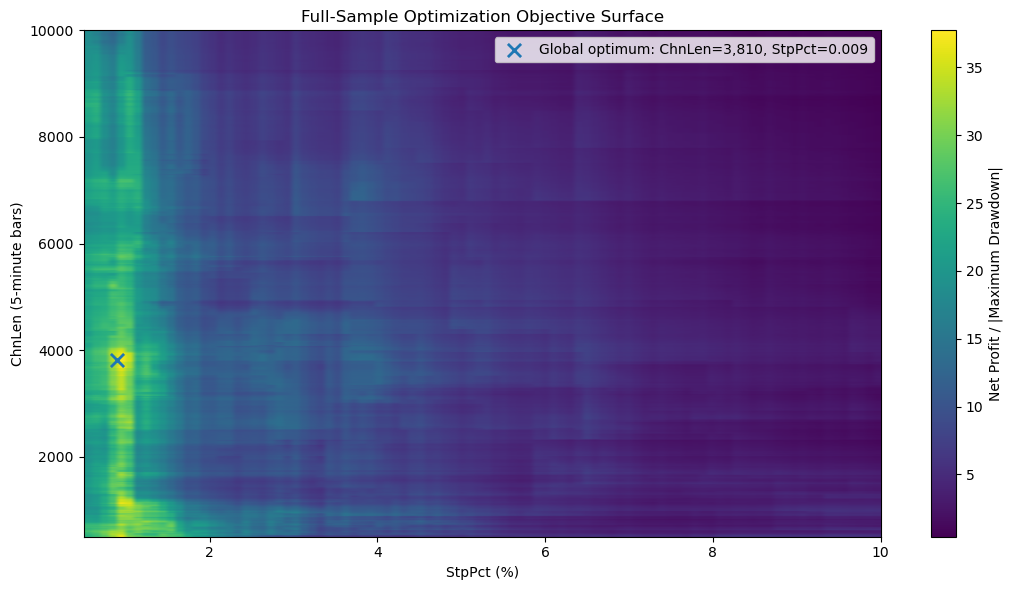

In [12]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

# ------------------------------------------------------------
# Objective surface
# ------------------------------------------------------------

im = ax.imshow(
    SCORE_SURFACE,
    aspect='auto',
    origin='lower',
    extent=[
        STPPCT_RANGE[0] * 100,
        STPPCT_RANGE[-1] * 100,
        CHNLEN_RANGE[0],
        CHNLEN_RANGE[-1]
    ]
)

# ------------------------------------------------------------
# Mark global optimum
# ------------------------------------------------------------

ax.scatter(
    BEST_STP * 100,
    BEST_CHN,
    marker='x',
    s=90,
    linewidths=2.0,
    label=(
        f'Global optimum: '
        f'ChnLen={BEST_CHN:,}, '
        f'StpPct={BEST_STP:.3f}'
    )
)

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_title(
    'Full-Sample Optimization Objective Surface'
)

ax.set_xlabel(
    'StpPct (%)'
)

ax.set_ylabel(
    'ChnLen (5-minute bars)'
)

ax.legend(
    loc='upper right'
)

cbar = fig.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    'Net Profit / |Maximum Drawdown|'
)

plt.tight_layout()
plt.show()

### 3.5 Local Neighborhood Analysis

Because the strongest objective values are concentrated in the lower portion of
the `StpPct` range, the neighborhood surrounding the global optimum is examined
more closely.

The local analysis evaluates the stored objective surface around the optimal
parameter pair without performing any additional optimization. This helps
determine whether performance deteriorates sharply when `ChnLen` or `StpPct`
moves slightly away from the exact optimum.

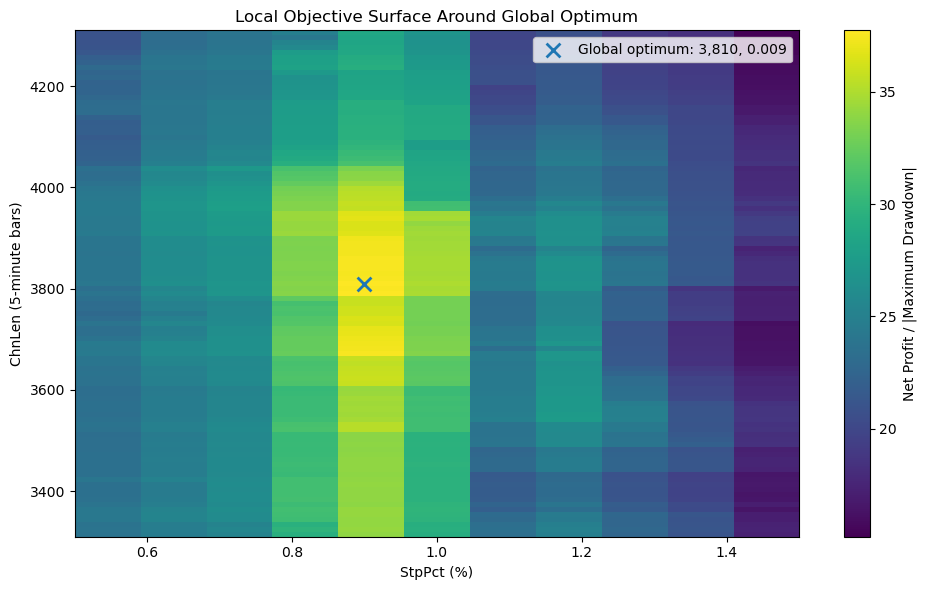

LOCAL NEIGHBORHOOD DIAGNOSTICS
--------------------------------------------------
ChnLen range:       3,310 -> 4,310
StpPct range:       0.005 -> 0.015
Local combinations: 1,111
Global objective:   37.736458
>= 90% of optimum:  86 (7.74%)
>= 80% of optimum:  194 (17.46%)


In [13]:
# ------------------------------------------------------------
# Define neighborhood around the global optimum
# ------------------------------------------------------------

LOCAL_CHN_MIN = max(
    CHNLEN_RANGE[0],
    BEST_CHN - 500
)

LOCAL_CHN_MAX = min(
    CHNLEN_RANGE[-1],
    BEST_CHN + 500
)

LOCAL_STP_MIN = max(
    STPPCT_RANGE[0],
    BEST_STP - 0.004
)

LOCAL_STP_MAX = min(
    STPPCT_RANGE[-1],
    BEST_STP + 0.006
)


# ------------------------------------------------------------
# Locate corresponding surface indices
# ------------------------------------------------------------

chn_mask = (
    (CHNLEN_RANGE >= LOCAL_CHN_MIN)
    & (CHNLEN_RANGE <= LOCAL_CHN_MAX)
)

stp_mask = (
    (STPPCT_RANGE >= LOCAL_STP_MIN)
    & (STPPCT_RANGE <= LOCAL_STP_MAX)
)

local_chn = (
    CHNLEN_RANGE[chn_mask]
)

local_stp = (
    STPPCT_RANGE[stp_mask]
)

local_scores = (
    SCORE_SURFACE[
        np.ix_(
            chn_mask,
            stp_mask
        )
    ]
)


# ------------------------------------------------------------
# Plot local objective surface
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)

im = ax.imshow(
    local_scores,
    aspect='auto',
    origin='lower',
    extent=[
        local_stp[0] * 100,
        local_stp[-1] * 100,
        local_chn[0],
        local_chn[-1]
    ]
)

ax.scatter(
    BEST_STP * 100,
    BEST_CHN,
    marker='x',
    s=100,
    linewidths=2.0,
    label=(
        f'Global optimum: '
        f'{BEST_CHN:,}, {BEST_STP:.3f}'
    )
)

ax.set_title(
    'Local Objective Surface Around Global Optimum'
)

ax.set_xlabel(
    'StpPct (%)'
)

ax.set_ylabel(
    'ChnLen (5-minute bars)'
)

ax.legend(
    loc='upper right'
)

cbar = fig.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    'Net Profit / |Maximum Drawdown|'
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Quantitative neighborhood diagnostics
# ------------------------------------------------------------

best_objective = float(
    BEST_SCORE
)

threshold_90 = (
    0.90 * best_objective
)

threshold_80 = (
    0.80 * best_objective
)

n_local = (
    local_scores.size
)

n_above_90 = int(
    np.sum(
        local_scores >= threshold_90
    )
)

n_above_80 = int(
    np.sum(
        local_scores >= threshold_80
    )
)


print(
    'LOCAL NEIGHBORHOOD DIAGNOSTICS'
)

print(
    '-' * 50
)

print(
    f'ChnLen range:       '
    f'{local_chn[0]:,} -> {local_chn[-1]:,}'
)

print(
    f'StpPct range:       '
    f'{local_stp[0]:.3f} -> {local_stp[-1]:.3f}'
)

print(
    f'Local combinations: {n_local:,}'
)

print(
    f'Global objective:   '
    f'{best_objective:.6f}'
)

print(
    f'>= 90% of optimum:  '
    f'{n_above_90:,} '
    f'({n_above_90 / n_local:.2%})'
)

print(
    f'>= 80% of optimum:  '
    f'{n_above_80:,} '
    f'({n_above_80 / n_local:.2%})'
)

## 4. Full-Sample Strategy Backtest

### 4.1 Detailed Backtest Engine

After identifying the global optimum, the strategy is rerun with a detailed
path-recording engine.

The trading logic is identical to the validated optimization engine, but the
detailed implementation additionally records:

- bar-level P&L;
- cumulative equity;
- dollar drawdown;
- position state;
- execution-event type;
- execution price.

These outputs are used for subsequent accounting validation, performance measurement, and trade-level analysis.

In [14]:
@njit(cache=True)
def run_strategy_detailed(
    high,
    low,
    close,
    hh,
    ll,
    start_idx,
    stp_pct,
    slpg,
    pv,
    initial_equity
):
    """
    Detailed Channel WithDDControl backtest engine.

    Event codes
    -----------
    0 : no execution event
    1 : both breakout channels crossed while flat
    2 : enter long
    3 : enter short
    4 : long -> short reversal
    5 : long trailing-stop exit
    6 : short -> long reversal
    7 : short trailing-stop exit

    Returns
    -------
    bar_pnl
    equity
    drawdown
    position_path
    event_code
    event_price
    """

    n = len(close)

    # --------------------------------------------------------
    # Output arrays
    # --------------------------------------------------------

    bar_pnl = np.zeros(
        n,
        dtype=np.float64
    )

    equity = np.full(
        n,
        initial_equity,
        dtype=np.float64
    )

    drawdown = np.zeros(
        n,
        dtype=np.float64
    )

    position_path = np.zeros(
        n,
        dtype=np.int8
    )

    event_code = np.zeros(
        n,
        dtype=np.int8
    )

    event_price = np.full(
        n,
        np.nan,
        dtype=np.float64
    )

    # --------------------------------------------------------
    # Strategy state
    # --------------------------------------------------------

    position = 0

    benchmark_long = np.nan
    benchmark_short = np.nan

    current_equity = initial_equity
    equity_max = initial_equity

    # ========================================================
    # Main strategy loop
    # ========================================================

    for k in range(
        start_idx,
        n
    ):

        # ----------------------------------------------------
        # Mark-to-market P&L from previous close
        # ----------------------------------------------------

        delta = (
            pv
            * (close[k] - close[k - 1])
            * position
        )

        traded = False

        # ====================================================
        # FLAT
        # ====================================================

        if position == 0:

            buy_signal = (
                high[k] >= hh[k]
            )

            sell_signal = (
                low[k] <= ll[k]
            )

            # ------------------------------------------------
            # Both channels crossed on same bar
            # Remain flat
            # ------------------------------------------------

            if (
                buy_signal
                and sell_signal
            ):

                delta = (
                    -slpg
                    + pv
                    * (
                        ll[k]
                        - hh[k]
                    )
                )

                event_code[k] = 1

            # ------------------------------------------------
            # Enter long
            # ------------------------------------------------

            elif buy_signal:

                delta = (
                    -slpg / 2.0
                    + pv
                    * (
                        close[k]
                        - hh[k]
                    )
                )

                position = 1
                traded = True

                benchmark_long = (
                    high[k]
                )

                benchmark_short = (
                    np.nan
                )

                event_code[k] = 2
                event_price[k] = hh[k]

            # ------------------------------------------------
            # Enter short
            # ------------------------------------------------

            elif sell_signal:

                delta = (
                    -slpg / 2.0
                    - pv
                    * (
                        close[k]
                        - ll[k]
                    )
                )

                position = -1
                traded = True

                benchmark_short = (
                    low[k]
                )

                benchmark_long = (
                    np.nan
                )

                event_code[k] = 3
                event_price[k] = ll[k]

        # ====================================================
        # LONG
        # ====================================================

        if (
            position == 1
            and not traded
        ):

            channel_reverse = (
                low[k] <= ll[k]
            )

            stop_price = (
                benchmark_long
                * (
                    1.0
                    - stp_pct
                )
            )

            stop_trigger = (
                low[k]
                <= stop_price
            )

            # ------------------------------------------------
            # Long -> short reversal
            # ------------------------------------------------

            if (
                channel_reverse
                and stop_trigger
            ):

                delta = (
                    delta
                    - slpg
                    - 2.0
                    * pv
                    * (
                        close[k]
                        - ll[k]
                    )
                )

                position = -1

                benchmark_short = (
                    low[k]
                )

                event_code[k] = 4
                event_price[k] = ll[k]

            else:

                # --------------------------------------------
                # Long trailing-stop exit
                # --------------------------------------------

                if stop_trigger:

                    delta = (
                        delta
                        - slpg / 2.0
                        - pv
                        * (
                            close[k]
                            - stop_price
                        )
                    )

                    position = 0

                    event_code[k] = 5
                    event_price[k] = stop_price

                # --------------------------------------------
                # Long -> short channel reversal
                # --------------------------------------------

                if channel_reverse:

                    delta = (
                        delta
                        - slpg
                        - 2.0
                        * pv
                        * (
                            close[k]
                            - ll[k]
                        )
                    )

                    position = -1

                    benchmark_short = (
                        low[k]
                    )

                    event_code[k] = 4
                    event_price[k] = ll[k]

            # ------------------------------------------------
            # Update long benchmark
            # ------------------------------------------------

            benchmark_long = max(
                high[k],
                benchmark_long
            )

        # ====================================================
        # SHORT
        # ====================================================

        if (
            position == -1
            and not traded
        ):

            channel_reverse = (
                high[k] >= hh[k]
            )

            stop_price = (
                benchmark_short
                * (
                    1.0
                    + stp_pct
                )
            )

            stop_trigger = (
                high[k]
                >= stop_price
            )

            # ------------------------------------------------
            # Short -> long reversal
            # ------------------------------------------------

            if (
                channel_reverse
                and stop_trigger
            ):

                delta = (
                    delta
                    - slpg
                    + 2.0
                    * pv
                    * (
                        close[k]
                        - hh[k]
                    )
                )

                position = 1

                benchmark_long = (
                    high[k]
                )

                event_code[k] = 6
                event_price[k] = hh[k]

            else:

                # --------------------------------------------
                # Short trailing-stop exit
                # --------------------------------------------

                if stop_trigger:

                    delta = (
                        delta
                        - slpg / 2.0
                        + pv
                        * (
                            close[k]
                            - stop_price
                        )
                    )

                    position = 0

                    event_code[k] = 7
                    event_price[k] = stop_price

                # --------------------------------------------
                # Short -> long channel reversal
                # --------------------------------------------

                if channel_reverse:

                    delta = (
                        delta
                        - slpg
                        + 2.0
                        * pv
                        * (
                            close[k]
                            - hh[k]
                        )
                    )

                    position = 1

                    benchmark_long = (
                        high[k]
                    )

                    event_code[k] = 6
                    event_price[k] = hh[k]

            # ------------------------------------------------
            # Update short benchmark
            # ------------------------------------------------

            benchmark_short = min(
                low[k],
                benchmark_short
            )

        # ====================================================
        # Store bar-level results
        # ====================================================

        current_equity += delta

        if current_equity > equity_max:
            equity_max = current_equity

        current_drawdown = (
            current_equity
            - equity_max
        )

        bar_pnl[k] = delta

        equity[k] = current_equity

        drawdown[k] = (
            current_drawdown
        )

        position_path[k] = (
            position
        )

    # --------------------------------------------------------
    # Carry initial values through warm-up region
    # --------------------------------------------------------

    for k in range(
        start_idx
    ):

        equity[k] = (
            initial_equity
        )

        drawdown[k] = 0.0
        position_path[k] = 0

    return (
        bar_pnl,
        equity,
        drawdown,
        position_path,
        event_code,
        event_price
    )


print(
    '4.1 Detailed backtest engine ready.'
)

4.1 Detailed backtest engine ready.


### 4.2 Run Optimal Full-Sample Strategy

The globally optimal parameter pair is now rerun using the detailed backtest
engine.

The detailed path must reproduce the optimization-stage results exactly.
Matching net profit, maximum drawdown, and optimization objective confirms that
the path-recording engine is fully consistent with the validated scoring engine.

In [15]:
# ------------------------------------------------------------
# Build channels for the globally optimal ChnLen
# ------------------------------------------------------------

BEST_HH, BEST_LL = build_channels_deque(
    H,
    L,
    BEST_CHN
)


# ------------------------------------------------------------
# Run detailed full-sample strategy
# ------------------------------------------------------------

(
    FULL_BAR_PNL,
    FULL_EQUITY,
    FULL_DRAWDOWN,
    FULL_POSITION,
    FULL_EVENT_CODE,
    FULL_EVENT_PRICE
) = run_strategy_detailed(
    H,
    L,
    C,
    BEST_HH,
    BEST_LL,
    BEST_CHN,
    BEST_STP,
    SLPG,
    PV,
    INITIAL_EQUITY
)


# ------------------------------------------------------------
# Detailed-path results
# ------------------------------------------------------------

DETAILED_END_EQUITY = float(
    FULL_EQUITY[-1]
)

DETAILED_NET_PROFIT = (
    DETAILED_END_EQUITY
    - INITIAL_EQUITY
)

DETAILED_MAXDD = float(
    np.min(
        FULL_DRAWDOWN
    )
)

if DETAILED_MAXDD < 0:

    DETAILED_SCORE = (
        DETAILED_NET_PROFIT
        / abs(
            DETAILED_MAXDD
        )
    )

else:

    DETAILED_SCORE = np.nan


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print(
    'OPTIMAL FULL-SAMPLE STRATEGY'
)

print(
    '-' * 50
)

print(
    f'ChnLen:             '
    f'{BEST_CHN:,}'
)

print(
    f'StpPct:             '
    f'{BEST_STP:.3f} '
    f'({BEST_STP:.1%})'
)

print(
    f'Starting equity:    '
    f'${INITIAL_EQUITY:,.2f}'
)

print(
    f'Ending equity:      '
    f'${DETAILED_END_EQUITY:,.2f}'
)

print(
    f'Net profit:         '
    f'${DETAILED_NET_PROFIT:,.2f}'
)

print(
    f'Max drawdown:       '
    f'${DETAILED_MAXDD:,.2f}'
)

print(
    f'Optimization obj.:  '
    f'{DETAILED_SCORE:.6f}'
)


# ------------------------------------------------------------
# Reconciliation with optimization-stage results
# ------------------------------------------------------------

print(
    '\nOPTIMIZER RECONCILIATION'
)

print(
    '-' * 50
)

print(
    f'Net profit error:   '
    f'${DETAILED_NET_PROFIT - BEST_PROFIT:,.10f}'
)

print(
    f'Max DD error:       '
    f'${DETAILED_MAXDD - BEST_MAXDD:,.10f}'
)

print(
    f'Objective error:    '
    f'{DETAILED_SCORE - BEST_SCORE:.10f}'
)

print(
    '\nDetailed engine matches optimizer:',
    bool(
        np.isclose(
            DETAILED_NET_PROFIT,
            BEST_PROFIT
        )
        and np.isclose(
            DETAILED_MAXDD,
            BEST_MAXDD
        )
        and np.isclose(
            DETAILED_SCORE,
            BEST_SCORE
        )
    )
)

OPTIMAL FULL-SAMPLE STRATEGY
--------------------------------------------------
ChnLen:             3,810
StpPct:             0.009 (0.9%)
Starting equity:    $100,000.00
Ending equity:      $266,511.65
Net profit:         $166,511.65
Max drawdown:       $-4,412.49
Optimization obj.:  37.736458

OPTIMIZER RECONCILIATION
--------------------------------------------------
Net profit error:   $0.0000000000
Max DD error:       $0.0000000000
Objective error:    0.0000000000

Detailed engine matches optimizer: True


### 4.3 Accounting Validation

Before calculating performance statistics, the detailed backtest path is
validated internally.

The checks verify that:

- cumulative bar-level P&L reconciles exactly with the change in equity;
- the stored equity path matches a direct cumulative-P&L reconstruction;
- the stored drawdown path matches an independently reconstructed drawdown;
- no trades or P&L occur during the channel warm-up period;
- the first tradable bar is exactly `ChnLen`;
- all recorded strategy outputs contain valid values over the evaluation period.

These checks ensure that subsequent performance and trade-level statistics are
calculated from an internally consistent backtest path.

In [16]:
# ------------------------------------------------------------
# Independent equity reconstruction from bar-level P&L
# ------------------------------------------------------------

equity_reconstructed = (
    INITIAL_EQUITY
    + np.cumsum(
        FULL_BAR_PNL
    )
)


# ------------------------------------------------------------
# Independent drawdown reconstruction
# ------------------------------------------------------------

running_peak_reconstructed = np.maximum.accumulate(
    equity_reconstructed
)

drawdown_reconstructed = (
    equity_reconstructed
    - running_peak_reconstructed
)


# ------------------------------------------------------------
# Core reconciliation errors
# ------------------------------------------------------------

pnl_sum = float(
    np.sum(
        FULL_BAR_PNL
    )
)

equity_change = float(
    FULL_EQUITY[-1]
    - INITIAL_EQUITY
)

equity_reconciliation_error = (
    pnl_sum
    - equity_change
)

equity_path_max_error = float(
    np.max(
        np.abs(
            FULL_EQUITY
            - equity_reconstructed
        )
    )
)

drawdown_path_max_error = float(
    np.max(
        np.abs(
            FULL_DRAWDOWN
            - drawdown_reconstructed
        )
    )
)


# ------------------------------------------------------------
# Warm-up checks
# ------------------------------------------------------------

warmup_pnl = float(
    np.sum(
        np.abs(
            FULL_BAR_PNL[
                :BEST_CHN
            ]
        )
    )
)

warmup_events = int(
    np.sum(
        FULL_EVENT_CODE[
            :BEST_CHN
        ] != 0
    )
)

warmup_positions = int(
    np.sum(
        FULL_POSITION[
            :BEST_CHN
        ] != 0
    )
)


# ------------------------------------------------------------
# Evaluation-period validity
# ------------------------------------------------------------

valid_equity = bool(
    np.all(
        np.isfinite(
            FULL_EQUITY[
                BEST_CHN:
            ]
        )
    )
)

valid_drawdown = bool(
    np.all(
        np.isfinite(
            FULL_DRAWDOWN[
                BEST_CHN:
            ]
        )
    )
)

valid_pnl = bool(
    np.all(
        np.isfinite(
            FULL_BAR_PNL[
                BEST_CHN:
            ]
        )
    )
)


# ------------------------------------------------------------
# Validation table
# ------------------------------------------------------------

accounting_validation = pd.DataFrame(
    {
        'Check': [
            'Bar P&L reconciles with ending equity',
            'Stored equity matches cumulative-P&L reconstruction',
            'Stored drawdown matches independent reconstruction',
            'No P&L during warm-up',
            'No execution events during warm-up',
            'No positions during warm-up',
            'First tradable index equals ChnLen',
            'Evaluation-period equity is finite',
            'Evaluation-period drawdown is finite',
            'Evaluation-period bar P&L is finite'
        ],

        'Passed': [
            np.isclose(
                equity_reconciliation_error,
                0.0
            ),

            np.isclose(
                equity_path_max_error,
                0.0
            ),

            np.isclose(
                drawdown_path_max_error,
                0.0
            ),

            np.isclose(
                warmup_pnl,
                0.0
            ),

            warmup_events == 0,

            warmup_positions == 0,

            BEST_CHN == 3810,

            valid_equity,

            valid_drawdown,

            valid_pnl
        ]
    }
)


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print(
    'FULL-SAMPLE ACCOUNTING VALIDATION'
)

print(
    '-' * 55
)

print(
    f'Bar-level P&L sum:       '
    f'${pnl_sum:,.2f}'
)

print(
    f'Ending equity change:    '
    f'${equity_change:,.2f}'
)

print(
    f'P&L reconciliation err.: '
    f'${equity_reconciliation_error:,.10f}'
)

print(
    f'Equity path max error:   '
    f'${equity_path_max_error:,.10f}'
)

print(
    f'Drawdown path max error: '
    f'${drawdown_path_max_error:,.10f}'
)

print(
    f'Warm-up bars:            '
    f'{BEST_CHN:,}'
)

print(
    f'Warm-up absolute P&L:    '
    f'${warmup_pnl:,.10f}'
)

print(
    f'Warm-up events:          '
    f'{warmup_events:,}'
)

print(
    f'Warm-up positions:       '
    f'{warmup_positions:,}'
)

print()

display(
    accounting_validation
)

print(
    '\nAll accounting checks passed:',
    bool(
        accounting_validation[
            'Passed'
        ].all()
    )
)

FULL-SAMPLE ACCOUNTING VALIDATION
-------------------------------------------------------
Bar-level P&L sum:       $166,511.65
Ending equity change:    $166,511.65
P&L reconciliation err.: $0.0000000005
Equity path max error:   $0.0000000005
Drawdown path max error: $0.0000000002
Warm-up bars:            3,810
Warm-up absolute P&L:    $0.0000000000
Warm-up events:          0
Warm-up positions:       0



,Check,Passed
0,Bar P&L reconciles with ending equity,True
1,Stored equity matches cumulative-P&L reconstru...,True
2,Stored drawdown matches independent reconstruc...,True
3,No P&L during warm-up,True
4,No execution events during warm-up,True
5,No positions during warm-up,True
6,First tradable index equals ChnLen,True
7,Evaluation-period equity is finite,True
8,Evaluation-period drawdown is finite,True
9,Evaluation-period bar P&L is finite,True



All accounting checks passed: True


### 4.4 Equity and Drawdown

The equity and drawdown paths are evaluated from the first tradable bar after
the `ChnLen` warm-up period.

The upper panel shows cumulative strategy equity, while the lower panel reports
dollar drawdown from the running equity peak. The maximum drawdown point is
marked explicitly.

Because Task 6 is a full-sample in-sample optimization, this figure describes
the fitted historical path of the globally optimal parameter pair and should
not be interpreted as out-of-sample evidence.

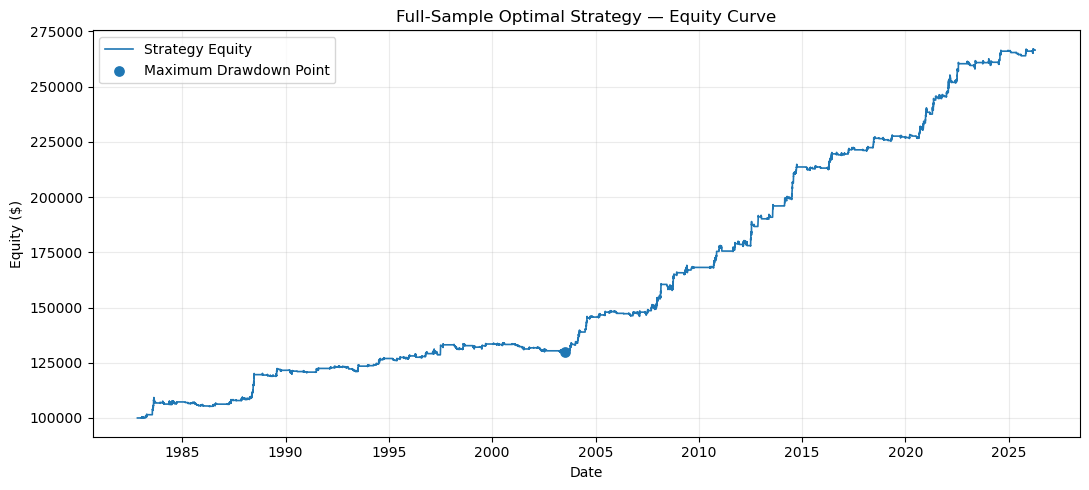

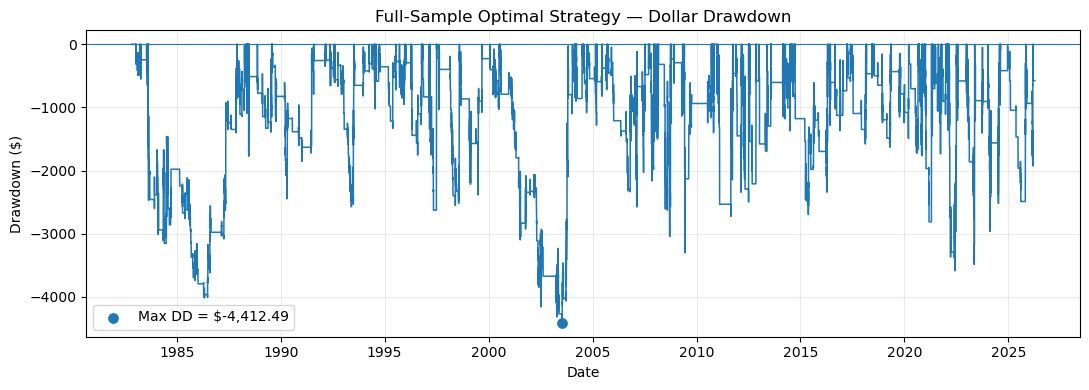

EQUITY / DRAWDOWN SUMMARY
--------------------------------------------------
First tradable bar: 1982-10-29T12:05:00.000000000
Last bar:           2026-04-10T13:15:00.000000000
Ending equity:      $266,511.65
Max drawdown:       $-4,412.49
Max DD timestamp:   2003-07-18T11:15:00.000000000


In [17]:
# ------------------------------------------------------------
# Active evaluation period
# ------------------------------------------------------------

EVAL_TS = TS[
    BEST_CHN:
]

EVAL_EQUITY = FULL_EQUITY[
    BEST_CHN:
]

EVAL_DRAWDOWN = FULL_DRAWDOWN[
    BEST_CHN:
]


# ------------------------------------------------------------
# Maximum drawdown location
# ------------------------------------------------------------

maxdd_local_idx = int(
    np.argmin(
        EVAL_DRAWDOWN
    )
)

MAXDD_TS = (
    EVAL_TS[
        maxdd_local_idx
    ]
)

MAXDD_VALUE = float(
    EVAL_DRAWDOWN[
        maxdd_local_idx
    ]
)


# ------------------------------------------------------------
# Plot equity curve
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.plot(
    EVAL_TS,
    EVAL_EQUITY,
    linewidth=1.2,
    label='Strategy Equity'
)

ax.scatter(
    MAXDD_TS,
    EVAL_EQUITY[
        maxdd_local_idx
    ],
    marker='o',
    s=45,
    label='Maximum Drawdown Point'
)

ax.set_title(
    'Full-Sample Optimal Strategy — Equity Curve'
)

ax.set_xlabel(
    'Date'
)

ax.set_ylabel(
    'Equity ($)'
)

ax.legend(
    loc='upper left'
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot dollar drawdown
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 4)
)

ax.plot(
    EVAL_TS,
    EVAL_DRAWDOWN,
    linewidth=1.1
)

ax.scatter(
    MAXDD_TS,
    MAXDD_VALUE,
    marker='o',
    s=45,
    label=(
        f'Max DD = '
        f'${MAXDD_VALUE:,.2f}'
    )
)

ax.axhline(
    0,
    linewidth=0.8
)

ax.set_title(
    'Full-Sample Optimal Strategy — Dollar Drawdown'
)

ax.set_xlabel(
    'Date'
)

ax.set_ylabel(
    'Drawdown ($)'
)

ax.legend(
    loc='lower left'
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Figure diagnostics
# ------------------------------------------------------------

print(
    'EQUITY / DRAWDOWN SUMMARY'
)

print(
    '-' * 50
)

print(
    f'First tradable bar: '
    f'{EVAL_TS[0]}'
)

print(
    f'Last bar:           '
    f'{EVAL_TS[-1]}'
)

print(
    f'Ending equity:      '
    f'${EVAL_EQUITY[-1]:,.2f}'
)

print(
    f'Max drawdown:       '
    f'${MAXDD_VALUE:,.2f}'
)

print(
    f'Max DD timestamp:   '
    f'{MAXDD_TS}'
)

### 4.5 Performance Metrics

Performance statistics are calculated over the active strategy period beginning
at the first tradable bar after channel warm-up.

To maintain consistency with the walk-forward analysis in Task 5, the Sharpe
ratio is calculated from daily percentage changes in strategy equity and
annualized using `sqrt(252)`.

The optimization objective is reported separately from the Calmar ratio:

- **Optimization Objective** = `Net Profit / |Maximum Dollar Drawdown|`
- **Calmar Ratio** = `CAGR / |Maximum Percentage Drawdown|`

Because the strategy was optimized over this same full sample, all statistics
in this section are in-sample performance measures.

In [18]:
# ------------------------------------------------------------
# Active strategy period
# ------------------------------------------------------------

perf = pd.DataFrame(
    {
        'ts': pd.to_datetime(
            EVAL_TS
        ),
        'equity': EVAL_EQUITY,
        'drawdown_dollar': EVAL_DRAWDOWN
    }
)

perf = (
    perf
    .sort_values('ts')
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Evaluation length
# ------------------------------------------------------------

start_ts = pd.Timestamp(
    perf['ts'].iloc[0]
)

end_ts = pd.Timestamp(
    perf['ts'].iloc[-1]
)

elapsed_years = (
    (end_ts - start_ts).total_seconds()
    / (
        365.25
        * 24
        * 60
        * 60
    )
)


# ------------------------------------------------------------
# Total return and CAGR
# ------------------------------------------------------------

start_equity = float(
    INITIAL_EQUITY
)

end_equity = float(
    perf['equity'].iloc[-1]
)

net_profit = (
    end_equity
    - start_equity
)

total_return = (
    end_equity
    / start_equity
    - 1.0
)

cagr = (
    (
        end_equity
        / start_equity
    )
    ** (
        1.0
        / elapsed_years
    )
    - 1.0
)


# ------------------------------------------------------------
# Percentage drawdown
# ------------------------------------------------------------

equity_values = (
    perf['equity']
    .to_numpy()
)

running_peak = np.maximum.accumulate(
    equity_values
)

drawdown_pct = (
    equity_values
    / running_peak
    - 1.0
)

max_drawdown_pct = float(
    np.min(
        drawdown_pct
    )
)

max_drawdown_dollar = float(
    np.min(
        perf['drawdown_dollar']
    )
)


# ------------------------------------------------------------
# Daily equity returns
# ------------------------------------------------------------

daily_equity = (
    perf
    .set_index('ts')['equity']
    .resample('1D')
    .last()
    .dropna()
)

daily_returns = (
    daily_equity
    .pct_change()
    .dropna()
)


# ------------------------------------------------------------
# Annualized daily Sharpe ratio
# ------------------------------------------------------------

if (
    len(daily_returns) > 1
    and daily_returns.std(
        ddof=1
    ) > 0
):

    daily_sharpe = (
        np.sqrt(252.0)
        * daily_returns.mean()
        / daily_returns.std(
            ddof=1
        )
    )

else:

    daily_sharpe = np.nan


# ------------------------------------------------------------
# Calmar ratio
# ------------------------------------------------------------

if max_drawdown_pct < 0:

    calmar_ratio = (
        cagr
        / abs(
            max_drawdown_pct
        )
    )

else:

    calmar_ratio = np.nan


# ------------------------------------------------------------
# Optimization objective
# ------------------------------------------------------------

optimization_objective = (
    net_profit
    / abs(
        max_drawdown_dollar
    )
)


# ------------------------------------------------------------
# Performance summary
# ------------------------------------------------------------

performance_summary = pd.DataFrame(
    {
        'Metric': [
            'Start Date',
            'End Date',
            'Evaluation Years',
            'Starting Equity',
            'Ending Equity',
            'Net Profit',
            'Total Return',
            'CAGR',
            'Maximum Drawdown ($)',
            'Maximum Drawdown (%)',
            'Daily Sharpe Ratio',
            'Calmar Ratio',
            'Optimization Objective'
        ],

        'Value': [
            str(start_ts),
            str(end_ts),
            f'{elapsed_years:.2f}',
            f'${start_equity:,.2f}',
            f'${end_equity:,.2f}',
            f'${net_profit:,.2f}',
            f'{total_return:.2%}',
            f'{cagr:.2%}',
            f'${max_drawdown_dollar:,.2f}',
            f'{max_drawdown_pct:.2%}',
            f'{daily_sharpe:.4f}',
            f'{calmar_ratio:.4f}',
            f'{optimization_objective:.6f}'
        ]
    }
)


print(
    'FULL-SAMPLE PERFORMANCE SUMMARY'
)

print(
    '-' * 55
)

display(
    performance_summary
)


print(
    '\nDAILY RETURN DIAGNOSTICS'
)

print(
    '-' * 55
)

print(
    f'Daily observations: '
    f'{len(daily_returns):,}'
)

print(
    f'Mean daily return:  '
    f'{daily_returns.mean():.8f}'
)

print(
    f'Daily volatility:   '
    f'{daily_returns.std(ddof=1):.8f}'
)

print(
    f'Annualized Sharpe:  '
    f'{daily_sharpe:.4f}'
)

FULL-SAMPLE PERFORMANCE SUMMARY
-------------------------------------------------------


,Metric,Value
0,Start Date,1982-10-29 12:05:00
1,End Date,2026-04-10 13:15:00
2,Evaluation Years,43.45
3,Starting Equity,"$100,000.00"
4,Ending Equity,"$266,511.65"
5,Net Profit,"$166,511.65"
6,Total Return,166.51%
7,CAGR,2.28%
8,Maximum Drawdown ($),"$-4,412.49"
9,Maximum Drawdown (%),-3.68%



DAILY RETURN DIAGNOSTICS
-------------------------------------------------------
Daily observations: 10,952
Mean daily return:  0.00009023
Daily volatility:   0.00120266
Annualized Sharpe:  1.1910


## 4.6 Trade-Level Analysis

### 4.6.1 Execution Event Summary

Before constructing the completed-trade ledger, the execution events generated
by the detailed backtest engine are summarized and validated.

The event codes distinguish initial entries, trailing-stop exits, directional
reversals, and the rare case in which both breakout channels are crossed while
the strategy is flat.

Reviewing these events first provides an independent check that the recorded
execution path is suitable for subsequent trade-level reconstruction.

In [19]:
# ------------------------------------------------------------
# Event-code definitions
# ------------------------------------------------------------

EVENT_LABELS = {
    0: 'No execution event',
    1: 'Both channels crossed while flat',
    2: 'Enter long',
    3: 'Enter short',
    4: 'Long -> short reversal',
    5: 'Long trailing-stop exit',
    6: 'Short -> long reversal',
    7: 'Short trailing-stop exit'
}


# ------------------------------------------------------------
# Extract non-zero execution events
# ------------------------------------------------------------

event_mask = (
    FULL_EVENT_CODE != 0
)

event_indices = np.where(
    event_mask
)[0]


execution_events = pd.DataFrame(
    {
        'BarIndex': event_indices,
        'Timestamp': pd.to_datetime(
            TS[event_indices]
        ),
        'EventCode': FULL_EVENT_CODE[
            event_indices
        ].astype(int),
        'Event': [
            EVENT_LABELS[
                int(code)
            ]
            for code in FULL_EVENT_CODE[
                event_indices
            ]
        ],
        'ExecutionPrice': FULL_EVENT_PRICE[
            event_indices
        ],
        'PositionAfter': FULL_POSITION[
            event_indices
        ].astype(int),
        'BarPnL': FULL_BAR_PNL[
            event_indices
        ],
        'EquityAfter': FULL_EQUITY[
            event_indices
        ]
    }
)


# ------------------------------------------------------------
# Event counts
# ------------------------------------------------------------

event_summary_rows = []

for code in range(
    1,
    8
):

    count = int(
        np.sum(
            FULL_EVENT_CODE
            == code
        )
    )

    event_summary_rows.append(
        {
            'EventCode': code,
            'Event': EVENT_LABELS[
                code
            ],
            'Count': count
        }
    )


event_summary = pd.DataFrame(
    event_summary_rows
)


# ------------------------------------------------------------
# Basic event-path validation
# ------------------------------------------------------------

events_before_start = int(
    np.sum(
        FULL_EVENT_CODE[
            :BEST_CHN
        ] != 0
    )
)

event_timestamps_ordered = bool(
    execution_events[
        'Timestamp'
    ].is_monotonic_increasing
)

event_indices_unique = bool(
    execution_events[
        'BarIndex'
    ].is_unique
)

valid_event_codes = bool(
    execution_events[
        'EventCode'
    ].isin(
        range(
            1,
            8
        )
    ).all()
)

valid_event_prices = bool(
    execution_events.loc[
        execution_events[
            'EventCode'
        ] != 1,
        'ExecutionPrice'
    ].notna().all()
)


event_validation = pd.DataFrame(
    {
        'Check': [
            'No execution events during warm-up',
            'Execution timestamps are ordered',
            'At most one recorded event per bar',
            'All event codes are valid',
            'All executable events have recorded prices'
        ],

        'Passed': [
            events_before_start == 0,
            event_timestamps_ordered,
            event_indices_unique,
            valid_event_codes,
            valid_event_prices
        ]
    }
)


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print(
    'EXECUTION EVENT SUMMARY'
)

print(
    '-' * 60
)

print(
    f'Total recorded events: '
    f'{len(execution_events):,}'
)

print()

display(
    event_summary
)


print(
    '\nEVENT-PATH VALIDATION'
)

print(
    '-' * 60
)

display(
    event_validation
)


print(
    '\nAll event-path checks passed:',
    bool(
        event_validation[
            'Passed'
        ].all()
    )
)


print(
    '\nFIRST 10 EXECUTION EVENTS'
)

print(
    '-' * 60
)

display(
    execution_events.head(
        10
    )
)

EXECUTION EVENT SUMMARY
------------------------------------------------------------
Total recorded events: 2,138



,EventCode,Event,Count
0,1,Both channels crossed while flat,0
1,2,Enter long,622
2,3,Enter short,447
3,4,Long -> short reversal,0
4,5,Long trailing-stop exit,622
5,6,Short -> long reversal,0
6,7,Short trailing-stop exit,447



EVENT-PATH VALIDATION
------------------------------------------------------------


,Check,Passed
0,No execution events during warm-up,True
1,Execution timestamps are ordered,True
2,At most one recorded event per bar,True
3,All event codes are valid,True
4,All executable events have recorded prices,True



All event-path checks passed: True

FIRST 10 EXECUTION EVENTS
------------------------------------------------------------


,BarIndex,Timestamp,EventCode,Event,ExecutionPrice,PositionAfter,BarPnL,EquityAfter
0,5987,1983-01-10 09:45:00,2,Enter long,586.2500,1,19.7500,"100,019.7500"
1,6050,1983-01-11 11:15:00,5,Long trailing-stop exit,585.6810,0,-33.7000,"99,936.0500"
2,6087,1983-01-12 10:35:00,2,Enter long,591.0000,1,-30.2500,"99,905.8000"
3,6222,1983-01-17 10:35:00,5,Long trailing-stop exit,599.0595,0,-52.2750,"100,303.5250"
4,6703,1983-01-31 13:10:00,2,Enter long,604.5000,1,-17.7500,"100,285.7750"
5,6727,1983-02-01 11:25:00,5,Long trailing-stop exit,602.0325,0,-41.1250,"100,144.6500"
6,7200,1983-02-16 09:35:00,2,Enter long,607.5000,1,207.2500,"100,351.9000"
7,7244,1983-02-16 13:15:00,5,Long trailing-stop exit,608.7218,0,-69.1625,"100,170.2375"
8,7288,1983-02-17 13:10:00,2,Enter long,614.2500,1,-55.2500,"100,114.9875"
9,7329,1983-02-18 12:50:00,5,Long trailing-stop exit,612.9335,0,-71.0750,"100,068.9125"


### 4.6.2 Completed-Trade Ledger

The validated execution sequence is converted into a completed-trade ledger.

Under the full-sample optimal parameter pair, every position is opened from flat
and subsequently closed by its corresponding trailing stop. No directional
reversals or same-bar dual-channel events occur.

Trade P&L is calculated directly from recorded execution prices and includes one
full round-turn slippage charge of $35.50 per completed trade.

In [20]:
trade_rows = []

open_trade = None


# ------------------------------------------------------------
# Process execution events chronologically
# ------------------------------------------------------------

for row in execution_events.itertuples(
    index=False
):

    code = int(
        row.EventCode
    )

    # ========================================================
    # LONG ENTRY
    # ========================================================

    if code == 2:

        if open_trade is not None:
            raise RuntimeError(
                'New long entry encountered while '
                'another trade is already open.'
            )

        open_trade = {
            'Direction': 'Long',
            'EntryBar': int(
                row.BarIndex
            ),
            'EntryTime': pd.Timestamp(
                row.Timestamp
            ),
            'EntryPrice': float(
                row.ExecutionPrice
            )
        }

    # ========================================================
    # SHORT ENTRY
    # ========================================================

    elif code == 3:

        if open_trade is not None:
            raise RuntimeError(
                'New short entry encountered while '
                'another trade is already open.'
            )

        open_trade = {
            'Direction': 'Short',
            'EntryBar': int(
                row.BarIndex
            ),
            'EntryTime': pd.Timestamp(
                row.Timestamp
            ),
            'EntryPrice': float(
                row.ExecutionPrice
            )
        }

    # ========================================================
    # LONG STOP EXIT
    # ========================================================

    elif code == 5:

        if (
            open_trade is None
            or open_trade[
                'Direction'
            ] != 'Long'
        ):
            raise RuntimeError(
                'Long stop exit encountered without '
                'a matching open long trade.'
            )

        exit_bar = int(
            row.BarIndex
        )

        exit_time = pd.Timestamp(
            row.Timestamp
        )

        exit_price = float(
            row.ExecutionPrice
        )

        gross_pnl = (
            PV
            * (
                exit_price
                - open_trade[
                    'EntryPrice'
                ]
            )
        )

        net_pnl = (
            gross_pnl
            - SLPG
        )

        holding_bars = (
            exit_bar
            - open_trade[
                'EntryBar'
            ]
        )

        trade_rows.append(
            {
                'Direction':
                    'Long',

                'EntryBar':
                    open_trade[
                        'EntryBar'
                    ],

                'ExitBar':
                    exit_bar,

                'EntryTime':
                    open_trade[
                        'EntryTime'
                    ],

                'ExitTime':
                    exit_time,

                'EntryPrice':
                    open_trade[
                        'EntryPrice'
                    ],

                'ExitPrice':
                    exit_price,

                'GrossPnL':
                    gross_pnl,

                'Slippage':
                    SLPG,

                'NetPnL':
                    net_pnl,

                'HoldingBars':
                    holding_bars
            }
        )

        open_trade = None

    # ========================================================
    # SHORT STOP EXIT
    # ========================================================

    elif code == 7:

        if (
            open_trade is None
            or open_trade[
                'Direction'
            ] != 'Short'
        ):
            raise RuntimeError(
                'Short stop exit encountered without '
                'a matching open short trade.'
            )

        exit_bar = int(
            row.BarIndex
        )

        exit_time = pd.Timestamp(
            row.Timestamp
        )

        exit_price = float(
            row.ExecutionPrice
        )

        gross_pnl = (
            PV
            * (
                open_trade[
                    'EntryPrice'
                ]
                - exit_price
            )
        )

        net_pnl = (
            gross_pnl
            - SLPG
        )

        holding_bars = (
            exit_bar
            - open_trade[
                'EntryBar'
            ]
        )

        trade_rows.append(
            {
                'Direction':
                    'Short',

                'EntryBar':
                    open_trade[
                        'EntryBar'
                    ],

                'ExitBar':
                    exit_bar,

                'EntryTime':
                    open_trade[
                        'EntryTime'
                    ],

                'ExitTime':
                    exit_time,

                'EntryPrice':
                    open_trade[
                        'EntryPrice'
                    ],

                'ExitPrice':
                    exit_price,

                'GrossPnL':
                    gross_pnl,

                'Slippage':
                    SLPG,

                'NetPnL':
                    net_pnl,

                'HoldingBars':
                    holding_bars
            }
        )

        open_trade = None

    # ========================================================
    # Reversal / dual-channel events
    # These are not expected for the optimal full-sample path.
    # ========================================================

    elif code in (
        1,
        4,
        6
    ):

        raise RuntimeError(
            f'Unexpected event code {code} '
            f'at {row.Timestamp}.'
        )


# ------------------------------------------------------------
# Construct completed-trade ledger
# ------------------------------------------------------------

trade_ledger = pd.DataFrame(
    trade_rows
)


# ------------------------------------------------------------
# Add sequential Trade ID
# ------------------------------------------------------------

trade_ledger.insert(
    0,
    'TradeID',
    np.arange(
        1,
        len(trade_ledger) + 1
    )
)


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print(
    'COMPLETED-TRADE LEDGER'
)

print(
    '-' * 60
)

print(
    f'Completed trades: '
    f'{len(trade_ledger):,}'
)

print(
    f'Open position remaining at end: '
    f'{open_trade is not None}'
)

print(
    f'Long trades: '
    f'{(trade_ledger["Direction"] == "Long").sum():,}'
)

print(
    f'Short trades: '
    f'{(trade_ledger["Direction"] == "Short").sum():,}'
)

print(
    f'Total ledger Net P&L: '
    f'${trade_ledger["NetPnL"].sum():,.2f}'
)


print(
    '\nFIRST 10 COMPLETED TRADES'
)

print(
    '-' * 60
)

display(
    trade_ledger.head(
        10
    )
)

COMPLETED-TRADE LEDGER
------------------------------------------------------------
Completed trades: 1,069
Open position remaining at end: False
Long trades: 622
Short trades: 447
Total ledger Net P&L: $166,511.65

FIRST 10 COMPLETED TRADES
------------------------------------------------------------


,TradeID,Direction,EntryBar,ExitBar,EntryTime,ExitTime,EntryPrice,ExitPrice,GrossPnL,Slippage,NetPnL,HoldingBars
0,1,Long,5987,6050,1983-01-10 09:45:00,1983-01-11 11:15:00,586.2500,585.6810,-28.4500,35.5000,-63.9500,63
1,2,Long,6087,6222,1983-01-12 10:35:00,1983-01-17 10:35:00,591.0000,599.0595,402.9750,35.5000,367.4750,135
2,3,Long,6703,6727,1983-01-31 13:10:00,1983-02-01 11:25:00,604.5000,602.0325,-123.3750,35.5000,-158.8750,24
3,4,Long,7200,7244,1983-02-16 09:35:00,1983-02-16 13:15:00,607.5000,608.7218,61.0875,35.5000,25.5875,44
4,5,Long,7288,7329,1983-02-17 13:10:00,1983-02-18 12:50:00,614.2500,612.9335,-65.8250,35.5000,-101.3250,41
5,6,Long,8280,8326,1983-03-23 09:35:00,1983-03-24 09:40:00,618.5000,631.7625,663.1250,35.5000,627.6250,46
6,7,Long,8455,8505,1983-03-28 12:55:00,1983-03-30 09:35:00,637.5000,637.7085,10.4250,35.5000,-25.0750,50
7,8,Long,8597,8640,1983-04-04 09:45:00,1983-04-05 09:35:00,643.5000,641.1770,-116.1500,35.5000,-151.6500,43
8,9,Long,8783,8837,1983-04-08 10:15:00,1983-04-11 11:00:00,647.0000,666.9430,997.1500,35.5000,961.6500,54
9,10,Long,11970,12022,1983-07-20 09:35:00,1983-07-21 10:10:00,673.0000,720.2092,"2,360.4625",35.5000,"2,324.9625",52


### 4.6.3 Trade-Ledger Validation

The completed-trade ledger is reconciled with the portfolio-level backtest
before trade statistics are calculated.

Because the optimal full-sample path contains no reversals, no same-bar
dual-channel events, and no open position at the end of the sample, completed
trade P&L should reconcile directly with total portfolio P&L.

Additional checks verify entry/exit ordering, positive holding periods,
directional consistency, transaction-cost accounting, and the correspondence
between execution events and completed trades.

In [21]:
# ------------------------------------------------------------
# Portfolio vs. ledger reconciliation
# ------------------------------------------------------------

portfolio_net_pnl = float(
    FULL_EQUITY[-1]
    - INITIAL_EQUITY
)

ledger_net_pnl = float(
    trade_ledger[
        'NetPnL'
    ].sum()
)

ledger_gross_pnl = float(
    trade_ledger[
        'GrossPnL'
    ].sum()
)

ledger_total_slippage = float(
    trade_ledger[
        'Slippage'
    ].sum()
)

ledger_reconciliation_error = (
    ledger_net_pnl
    - portfolio_net_pnl
)

cost_reconciliation_error = (
    ledger_gross_pnl
    - ledger_total_slippage
    - ledger_net_pnl
)


# ------------------------------------------------------------
# Trade-count reconciliation
# ------------------------------------------------------------

n_completed = len(
    trade_ledger
)

n_entries = int(
    np.sum(
        np.isin(
            FULL_EVENT_CODE,
            [2, 3]
        )
    )
)

n_exits = int(
    np.sum(
        np.isin(
            FULL_EVENT_CODE,
            [5, 7]
        )
    )
)

n_reversals = int(
    np.sum(
        np.isin(
            FULL_EVENT_CODE,
            [4, 6]
        )
    )
)

n_dual_channel = int(
    np.sum(
        FULL_EVENT_CODE == 1
    )
)


# ------------------------------------------------------------
# Structural trade checks
# ------------------------------------------------------------

entry_before_exit = bool(
    (
        trade_ledger[
            'EntryBar'
        ]
        <
        trade_ledger[
            'ExitBar'
        ]
    ).all()
)

positive_holding_period = bool(
    (
        trade_ledger[
            'HoldingBars'
        ]
        > 0
    ).all()
)

timestamps_ordered = bool(
    (
        trade_ledger[
            'EntryTime'
        ]
        <
        trade_ledger[
            'ExitTime'
        ]
    ).all()
)

valid_directions = bool(
    trade_ledger[
        'Direction'
    ].isin(
        [
            'Long',
            'Short'
        ]
    ).all()
)

constant_round_turn_cost = bool(
    np.allclose(
        trade_ledger[
            'Slippage'
        ].to_numpy(),
        SLPG
    )
)

no_open_position_at_end = bool(
    open_trade is None
    and FULL_POSITION[-1] == 0
)


# ------------------------------------------------------------
# Validation table
# ------------------------------------------------------------

trade_validation = pd.DataFrame(
    {
        'Check': [
            'Completed-trade P&L reconciles with portfolio P&L',
            'Gross P&L minus slippage equals net trade P&L',
            'Number of entries equals completed trades',
            'Number of exits equals completed trades',
            'No reversal events in optimal path',
            'No dual-channel flat events in optimal path',
            'Every entry occurs before its exit',
            'Every completed trade has positive holding bars',
            'Entry timestamps precede exit timestamps',
            'All trade directions are valid',
            'Every trade uses one round-turn slippage charge',
            'No position remains open at sample end'
        ],

        'Passed': [
            np.isclose(
                ledger_reconciliation_error,
                0.0
            ),

            np.isclose(
                cost_reconciliation_error,
                0.0
            ),

            n_entries
            == n_completed,

            n_exits
            == n_completed,

            n_reversals == 0,

            n_dual_channel == 0,

            entry_before_exit,

            positive_holding_period,

            timestamps_ordered,

            valid_directions,

            constant_round_turn_cost,

            no_open_position_at_end
        ]
    }
)


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print(
    'TRADE-LEDGER VALIDATION'
)

print(
    '-' * 60
)

print(
    f'Portfolio Net P&L:       '
    f'${portfolio_net_pnl:,.2f}'
)

print(
    f'Completed-trade Net P&L: '
    f'${ledger_net_pnl:,.2f}'
)

print(
    f'Ledger Gross P&L:        '
    f'${ledger_gross_pnl:,.2f}'
)

print(
    f'Total slippage:          '
    f'${ledger_total_slippage:,.2f}'
)

print(
    f'Ledger reconciliation:   '
    f'${ledger_reconciliation_error:,.10f}'
)

print(
    f'Cost reconciliation:     '
    f'${cost_reconciliation_error:,.10f}'
)

print(
    f'\nCompleted trades:        '
    f'{n_completed:,}'
)

print(
    f'Entry events:            '
    f'{n_entries:,}'
)

print(
    f'Exit events:             '
    f'{n_exits:,}'
)

print(
    f'Reversal events:         '
    f'{n_reversals:,}'
)

print(
    f'Dual-channel events:     '
    f'{n_dual_channel:,}'
)

print()

display(
    trade_validation
)

print(
    '\nAll trade-ledger checks passed:',
    bool(
        trade_validation[
            'Passed'
        ].all()
    )
)

TRADE-LEDGER VALIDATION
------------------------------------------------------------
Portfolio Net P&L:       $166,511.65
Completed-trade Net P&L: $166,511.65
Ledger Gross P&L:        $204,461.15
Total slippage:          $37,949.50
Ledger reconciliation:   $0.0000000005
Cost reconciliation:     $0.0000000000

Completed trades:        1,069
Entry events:            1,069
Exit events:             1,069
Reversal events:         0
Dual-channel events:     0



,Check,Passed
0,Completed-trade P&L reconciles with portfolio P&L,True
1,Gross P&L minus slippage equals net trade P&L,True
2,Number of entries equals completed trades,True
3,Number of exits equals completed trades,True
4,No reversal events in optimal path,True
5,No dual-channel flat events in optimal path,True
6,Every entry occurs before its exit,True
7,Every completed trade has positive holding bars,True
8,Entry timestamps precede exit timestamps,True
9,All trade directions are valid,True



All trade-ledger checks passed: True


### 4.6.4 Trade Statistics

Trade-level performance is summarized from the validated completed-trade
ledger.

The analysis reports overall profitability, payoff asymmetry, holding-period
characteristics, and the contribution of long and short trades. All statistics
are based on net trade P&L after the $35.50 round-turn slippage charge.

These trade statistics describe the in-sample behavior of the globally
optimized strategy and are interpreted separately from the portfolio-level
return and risk measures.

In [22]:
trade_pnl = (
    trade_ledger[
        'NetPnL'
    ].to_numpy()
)

winning_trades = (
    trade_pnl[
        trade_pnl > 0
    ]
)

losing_trades = (
    trade_pnl[
        trade_pnl < 0
    ]
)

flat_trades = (
    trade_pnl[
        trade_pnl == 0
    ]
)


# ------------------------------------------------------------
# Core trade statistics
# ------------------------------------------------------------

n_trades = len(
    trade_pnl
)

n_wins = len(
    winning_trades
)

n_losses = len(
    losing_trades
)

n_flat = len(
    flat_trades
)

win_rate = (
    n_wins
    / n_trades
)

gross_profit = float(
    winning_trades.sum()
)

gross_loss = float(
    losing_trades.sum()
)

profit_factor = (
    gross_profit
    / abs(gross_loss)
    if gross_loss < 0
    else np.nan
)

expectancy = float(
    trade_pnl.mean()
)

median_trade_pnl = float(
    np.median(
        trade_pnl
    )
)

avg_winner = (
    float(
        winning_trades.mean()
    )
    if n_wins > 0
    else np.nan
)

avg_loser = (
    float(
        losing_trades.mean()
    )
    if n_losses > 0
    else np.nan
)

payoff_ratio = (
    avg_winner
    / abs(avg_loser)
    if (
        np.isfinite(avg_winner)
        and np.isfinite(avg_loser)
        and avg_loser < 0
    )
    else np.nan
)


# ------------------------------------------------------------
# Holding-period statistics
# ------------------------------------------------------------

avg_holding_bars = float(
    trade_ledger[
        'HoldingBars'
    ].mean()
)

median_holding_bars = float(
    trade_ledger[
        'HoldingBars'
    ].median()
)

max_holding_bars = int(
    trade_ledger[
        'HoldingBars'
    ].max()
)


# ------------------------------------------------------------
# Long / short breakdown
# ------------------------------------------------------------

direction_rows = []

for direction in [
    'Long',
    'Short'
]:

    subset = trade_ledger.loc[
        trade_ledger[
            'Direction'
        ] == direction
    ]

    pnl = (
        subset[
            'NetPnL'
        ].to_numpy()
    )

    wins = (
        pnl[
            pnl > 0
        ]
    )

    losses = (
        pnl[
            pnl < 0
        ]
    )

    direction_pf = (
        wins.sum()
        / abs(
            losses.sum()
        )
        if len(losses) > 0
        else np.nan
    )

    direction_rows.append(
        {
            'Direction':
                direction,

            'Trades':
                len(subset),

            'Win Rate':
                (
                    np.mean(
                        pnl > 0
                    )
                ),

            'Net P&L':
                pnl.sum(),

            'Avg Trade':
                pnl.mean(),

            'Profit Factor':
                direction_pf,

            'Avg Holding Bars':
                subset[
                    'HoldingBars'
                ].mean()
        }
    )


direction_summary = pd.DataFrame(
    direction_rows
)


# ------------------------------------------------------------
# Overall summary table
# ------------------------------------------------------------

trade_statistics = pd.DataFrame(
    {
        'Metric': [
            'Completed Trades',
            'Winning Trades',
            'Losing Trades',
            'Flat Trades',
            'Win Rate',
            'Gross Profit',
            'Gross Loss',
            'Profit Factor',
            'Expectancy per Trade',
            'Median Trade P&L',
            'Average Winner',
            'Average Loser',
            'Winner / Loser Payoff Ratio',
            'Average Holding Bars',
            'Median Holding Bars',
            'Maximum Holding Bars'
        ],

        'Value': [
            f'{n_trades:,}',
            f'{n_wins:,}',
            f'{n_losses:,}',
            f'{n_flat:,}',
            f'{win_rate:.2%}',
            f'${gross_profit:,.2f}',
            f'${gross_loss:,.2f}',
            f'{profit_factor:.4f}',
            f'${expectancy:,.2f}',
            f'${median_trade_pnl:,.2f}',
            f'${avg_winner:,.2f}',
            f'${avg_loser:,.2f}',
            f'{payoff_ratio:.4f}',
            f'{avg_holding_bars:.2f}',
            f'{median_holding_bars:.0f}',
            f'{max_holding_bars:,}'
        ]
    }
)


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print(
    'OVERALL TRADE STATISTICS'
)

print(
    '-' * 60
)

display(
    trade_statistics
)


print(
    '\nLONG / SHORT BREAKDOWN'
)

print(
    '-' * 60
)

direction_display = (
    direction_summary.copy()
)

direction_display[
    'Win Rate'
] = direction_display[
    'Win Rate'
].map(
    lambda x:
    f'{x:.2%}'
)

direction_display[
    'Net P&L'
] = direction_display[
    'Net P&L'
].map(
    lambda x:
    f'${x:,.2f}'
)

direction_display[
    'Avg Trade'
] = direction_display[
    'Avg Trade'
].map(
    lambda x:
    f'${x:,.2f}'
)

direction_display[
    'Profit Factor'
] = direction_display[
    'Profit Factor'
].map(
    lambda x:
    f'{x:.4f}'
)

direction_display[
    'Avg Holding Bars'
] = direction_display[
    'Avg Holding Bars'
].map(
    lambda x:
    f'{x:.2f}'
)

display(
    direction_display
)

OVERALL TRADE STATISTICS
------------------------------------------------------------


,Metric,Value
0,Completed Trades,"1,069"
1,Winning Trades,462
2,Losing Trades,607
3,Flat Trades,0
4,Win Rate,43.22%
5,Gross Profit,"$315,706.84"
6,Gross Loss,"$-149,195.19"
7,Profit Factor,2.1161
8,Expectancy per Trade,$155.76
9,Median Trade P&L,$-73.30



LONG / SHORT BREAKDOWN
------------------------------------------------------------


,Direction,Trades,Win Rate,Net P&L,Avg Trade,Profit Factor,Avg Holding Bars
0,Long,622,42.60%,"$91,408.29",$146.96,1.9735,35.38
1,Short,447,44.07%,"$75,103.36",$168.02,2.3583,35.54


## 4.7 Trade P&L Distribution

The distribution of completed-trade net P&L illustrates the payoff structure
behind the strategy's positive expectancy.

Although fewer than half of completed trades are profitable and the median
trade P&L is negative, winning trades are substantially larger on average than
losing trades. This asymmetric payoff profile allows the strategy to generate
positive aggregate P&L despite a win rate below 50%.

The distribution is shown for descriptive purposes only; because the parameter
pair was selected on the same full sample, it represents in-sample behavior.

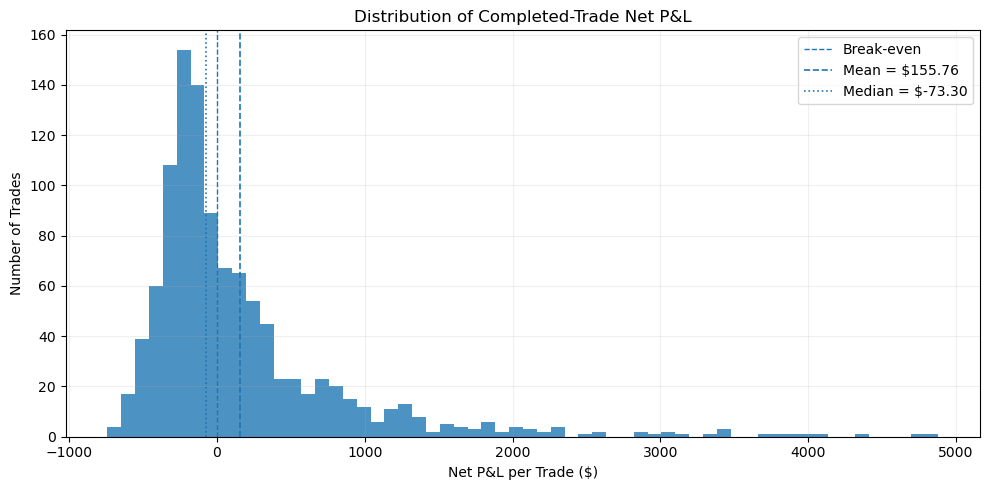

TRADE P&L DISTRIBUTION DIAGNOSTICS
------------------------------------------------------------
Mean:              $155.76
Median:            $-73.30
Standard deviation: $712.14
Minimum:           $-741.80
Maximum:           $4,883.02
Skewness:          2.7478

P&L QUANTILES
------------------------------------------------------------


,Quantile,Net P&L
0,1%,$-616.48
1,5%,$-470.44
2,25%,$-252.57
3,50%,$-73.30
4,75%,$298.10
5,95%,"$1,491.59"
6,99%,"$3,336.52"


In [23]:
trade_pnl_series = (
    trade_ledger[
        'NetPnL'
    ]
    .astype(float)
)


# ------------------------------------------------------------
# Plot completed-trade P&L distribution
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.hist(
    trade_pnl_series,
    bins=60,
    alpha=0.8
)

ax.axvline(
    0,
    linewidth=1.0,
    linestyle='--',
    label='Break-even'
)

ax.axvline(
    trade_pnl_series.mean(),
    linewidth=1.2,
    linestyle='--',
    label=(
        f'Mean = '
        f'${trade_pnl_series.mean():,.2f}'
    )
)

ax.axvline(
    trade_pnl_series.median(),
    linewidth=1.2,
    linestyle=':',
    label=(
        f'Median = '
        f'${trade_pnl_series.median():,.2f}'
    )
)

ax.set_title(
    'Distribution of Completed-Trade Net P&L'
)

ax.set_xlabel(
    'Net P&L per Trade ($)'
)

ax.set_ylabel(
    'Number of Trades'
)

ax.legend()

ax.grid(
    alpha=0.20
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Distribution diagnostics
# ------------------------------------------------------------

pnl_quantiles = (
    trade_pnl_series
    .quantile(
        [
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
)


print(
    'TRADE P&L DISTRIBUTION DIAGNOSTICS'
)

print(
    '-' * 60
)

print(
    f'Mean:              '
    f'${trade_pnl_series.mean():,.2f}'
)

print(
    f'Median:            '
    f'${trade_pnl_series.median():,.2f}'
)

print(
    f'Standard deviation:'
    f' ${trade_pnl_series.std(ddof=1):,.2f}'
)

print(
    f'Minimum:           '
    f'${trade_pnl_series.min():,.2f}'
)

print(
    f'Maximum:           '
    f'${trade_pnl_series.max():,.2f}'
)

print(
    f'Skewness:          '
    f'{trade_pnl_series.skew():.4f}'
)


print(
    '\nP&L QUANTILES'
)

print(
    '-' * 60
)

quantile_table = pd.DataFrame(
    {
        'Quantile': [
            '1%',
            '5%',
            '25%',
            '50%',
            '75%',
            '95%',
            '99%'
        ],

        'Net P&L': [
            f'${x:,.2f}'
            for x in pnl_quantiles.values
        ]
    }
)

display(
    quantile_table
)

# 5. Full-Sample Results Summary

## 5.1 Final Results Table

The table below consolidates the principal parameter, portfolio-level, and
trade-level results from the full-sample optimization.

These statistics summarize the best-performing parameter pair selected from all
91,296 prescribed combinations. Because both parameter selection and performance
evaluation use the same historical sample, the results represent an in-sample
benchmark rather than an estimate of out-of-sample performance.

In [24]:
task6_final_results = pd.DataFrame(
    {
        'Category': [
            'Optimization',
            'Optimization',
            'Optimization',
            'Optimization',
            'Portfolio',
            'Portfolio',
            'Portfolio',
            'Portfolio',
            'Portfolio',
            'Portfolio',
            'Portfolio',
            'Trades',
            'Trades',
            'Trades',
            'Trades',
            'Trades',
            'Trades',
            'Trades'
        ],

        'Metric': [
            'Optimal ChnLen',
            'Optimal StpPct',
            'Parameter Combinations',
            'Optimization Objective',
            'Ending Equity',
            'Net Profit',
            'Total Return',
            'CAGR',
            'Maximum Drawdown ($)',
            'Maximum Drawdown (%)',
            'Daily Sharpe Ratio',
            'Completed Trades',
            'Win Rate',
            'Profit Factor',
            'Expectancy per Trade',
            'Median Trade P&L',
            'Winner / Loser Payoff Ratio',
            'Average Holding Bars'
        ],

        'Value': [
            f'{BEST_CHN:,}',
            f'{BEST_STP:.3f} ({BEST_STP:.1%})',
            f'{len(CHNLEN_RANGE) * len(STPPCT_RANGE):,}',
            f'{BEST_SCORE:.6f}',
            f'${end_equity:,.2f}',
            f'${net_profit:,.2f}',
            f'{total_return:.2%}',
            f'{cagr:.2%}',
            f'${max_drawdown_dollar:,.2f}',
            f'{max_drawdown_pct:.2%}',
            f'{daily_sharpe:.4f}',
            f'{n_trades:,}',
            f'{win_rate:.2%}',
            f'{profit_factor:.4f}',
            f'${expectancy:,.2f}',
            f'${median_trade_pnl:,.2f}',
            f'{payoff_ratio:.4f}',
            f'{avg_holding_bars:.2f}'
        ]
    }
)


print(
    'TASK 6 — FINAL FULL-SAMPLE RESULTS'
)

print(
    '=' * 65
)

display(
    task6_final_results
)

TASK 6 — FINAL FULL-SAMPLE RESULTS


,Category,Metric,Value
0,Optimization,Optimal ChnLen,"3,810"
1,Optimization,Optimal StpPct,0.009 (0.9%)
2,Optimization,Parameter Combinations,"91,296"
3,Optimization,Optimization Objective,37.736458
4,Portfolio,Ending Equity,"$266,511.65"
5,Portfolio,Net Profit,"$166,511.65"
6,Portfolio,Total Return,166.51%
7,Portfolio,CAGR,2.28%
8,Portfolio,Maximum Drawdown ($),"$-4,412.49"
9,Portfolio,Maximum Drawdown (%),-3.68%


## 5.2 Interpretation and Key Findings

The exhaustive full-sample search identifies **ChnLen = 3,810** and
**StpPct = 0.009** as the global optimum among all **91,296** prescribed
parameter combinations. The corresponding optimization objective,
defined as Net Profit divided by the absolute maximum dollar drawdown,
is **37.7365**.

Using this parameter pair, the strategy grows initial equity from
**$100,000 to $266,511.65**, generating **$166,511.65** in net profit
over the active evaluation period. The resulting total return is
**166.51%**, with a **2.28% CAGR**, **1.1910 daily Sharpe ratio**, and
**-3.68% maximum percentage drawdown**. The optimization objective is
reported separately from the Calmar ratio because the former uses
cumulative dollar profit and dollar drawdown, whereas the latter uses
CAGR and percentage drawdown.

Trade-level results show a characteristic asymmetric trend-following
payoff profile. Across **1,069 completed trades**, the win rate is only
**43.22%**, but the average winning trade is approximately **2.78 times**
the magnitude of the average losing trade. This produces a
**2.1161 profit factor** and positive expectancy of **$155.76 per trade**.
The negative median trade P&L (**-$73.30**) together with strongly positive
skewness (**2.7478**) further indicates that aggregate profitability is
driven by relatively infrequent but substantially larger winning trades.

Both directions contribute positively to performance. Long trades generate
**$91,408.29** in net P&L, while short trades contribute **$75,103.36**.
The short side has fewer trades but a somewhat higher profit factor, indicating
that the full-sample result is not dependent exclusively on one directional
exposure.

The optimization surface also provides evidence that the selected solution is
not an isolated single-grid-point spike. Within the local neighborhood examined
around the global optimum, multiple nearby parameter combinations retain a
large proportion of the maximum objective value. This provides useful evidence
of local parameter robustness within the fitted sample.

However, these results must be interpreted strictly as an **in-sample
benchmark**. The same historical observations are used both to select the
optimal parameters and to evaluate their performance, so the results are
subject to optimization bias and do not constitute evidence of out-of-sample
generalization. The appropriate robustness test is therefore the rolling
walk-forward procedure from Task 5, which will be compared directly with this
full-sample benchmark in Task 7.